# Radar Receiver Architectures — From RF Pulse to IQ Baseband

A radar transmits a high-frequency pulse and listens for echoes. The **receiver** must convert the returned RF signal into a pair of baseband signals — **I** (In-phase) and **Q** (Quadrature) — that preserve both amplitude and phase information. This notebook traces the signal through every stage of three standard receiver architectures, with time-domain and frequency-domain plots at each step.

## Why I and Q?

A single real-valued baseband signal loses the **sign of the Doppler shift** — you cannot distinguish an approaching target from a receding one. The complex baseband representation

$$s_{BB}(t) = I(t) + j\,Q(t) = A(t)\,e^{j\phi(t)}$$

preserves both magnitude $A(t)$ (→ target range / RCS) and phase $\phi(t)$ (→ Doppler velocity, range resolution in pulse compression). Every modern radar receiver ultimately produces I/Q samples.

## Three Receiver Architectures

| Architecture | Down-conversion | IQ extraction | ADC position |
|:---|:---|:---|:---|
| **1. Superheterodyne (Analog IQ)** | RF → IF (analog mixer) | Analog quadrature mixer at IF | After IQ low-pass filters |
| **2. Digital IF** | RF → IF (analog mixer) | Digital down-conversion after ADC | At IF (before IQ extraction) |
| **3. Homodyne (Direct Conversion)** | RF → baseband directly | Analog quadrature mixer at RF | After IQ low-pass filters |

Each architecture trades off complexity, image rejection, DC offset, and required ADC speed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from scipy.signal import butter, sosfilt, firwin, lfilter
%matplotlib inline

plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
    'figure.dpi': 100, 'font.size': 11,
    'axes.labelsize': 11, 'axes.titlesize': 12,
})

# ── Radar parameters (scaled for visualization) ──
f_rf   = 200.0    # RF carrier frequency [Hz] (represents e.g. 10 GHz)
f_if   = 50.0     # Intermediate frequency [Hz]
f_lo   = f_rf - f_if  # LO frequency for superheterodyne
B_pulse = 15.0    # Pulse bandwidth [Hz]
tau     = 0.08    # Pulse duration [s]
f_d     = 3.0     # Doppler shift [Hz]
A_rx    = 0.6     # Received amplitude (attenuated)

# Time vectors
dur   = 0.35
t_c   = np.linspace(0, dur, 40000)   # continuous-time (high resolution)
dt_c  = t_c[1] - t_c[0]

def spectrum(sig, t, nfft=None):
    """Compute one-sided magnitude spectrum."""
    N = len(sig)
    if nfft is None:
        nfft = max(N * 4, 8192)
    dt = t[1] - t[0]
    freq = np.fft.rfftfreq(nfft, dt)
    mag  = 2 * np.abs(np.fft.rfft(sig, n=nfft)) / N
    return freq, mag

def spectrum_twosided(sig, t, nfft=None):
    """Compute two-sided magnitude spectrum."""
    N = len(sig)
    if nfft is None:
        nfft = max(N * 4, 8192)
    dt = t[1] - t[0]
    freq = np.fft.fftshift(np.fft.fftfreq(nfft, dt))
    mag  = np.fft.fftshift(np.abs(np.fft.fft(sig, n=nfft))) / N
    return freq, mag

def complex_spectrum_twosided(sig, t, nfft=None):
    """Two-sided spectrum for complex signals."""
    N = len(sig)
    if nfft is None:
        nfft = max(N * 4, 8192)
    dt = t[1] - t[0]
    freq = np.fft.fftshift(np.fft.fftfreq(nfft, dt))
    mag  = np.fft.fftshift(np.abs(np.fft.fft(sig, n=nfft))) / N
    return freq, mag

print(f"RF carrier:  {f_rf} Hz    IF: {f_if} Hz    LO: {f_lo} Hz")
print(f"Pulse BW:    {B_pulse} Hz   duration: {tau*1e3:.0f} ms")
print(f"Doppler:     {f_d} Hz")
print(f"Simulation:  {dur*1e3:.0f} ms,  {len(t_c)} samples,  dt = {dt_c*1e6:.1f} µs")

RF carrier:  200.0 Hz    IF: 50.0 Hz    LO: 150.0 Hz
Pulse BW:    15.0 Hz   duration: 80 ms
Doppler:     3.0 Hz
Simulation:  350 ms,  40000 samples,  dt = 8.8 µs


# Step 0 — The Received RF Pulse

The antenna captures a returned radar echo. For a simple pulsed radar with linear frequency modulation (chirp):

$$s_{RF}(t) = A_{rx}\, \operatorname{rect}\!\left(\frac{t - t_0}{\tau}\right) \cos\!\left(2\pi (f_{RF} + f_d)\,t + \pi \frac{B}{\tau}\,t^2\right)$$

- $f_{RF}$: carrier frequency (e.g. 10 GHz, here scaled to 200 Hz for visualization)
- $f_d$: Doppler shift from target motion
- $B/\tau$: chirp rate (linear FM sweep across bandwidth $B$ in pulse duration $\tau$)
- $A_{rx} \ll A_{tx}$: heavily attenuated by path loss ($\propto 1/R^4$)

This is a **real-valued, continuous-time, bandpass** signal centered at $f_{RF} + f_d$. Its spectrum is symmetric about the origin (conjugate symmetry), occupying bandwidth $B$ around $\pm f_{RF}$.

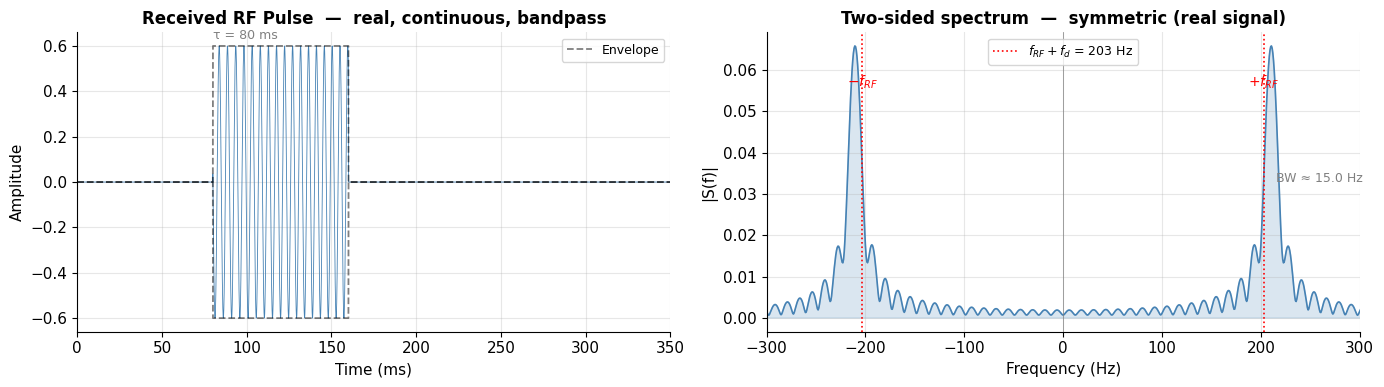

Signal type: REAL | CONTINUOUS | BANDPASS at ±f_RF


In [2]:
# ── Generate received RF pulse (LFM chirp with Doppler) ──
t0_pulse = 0.08                          # pulse start time
pulse_mask = (t_c >= t0_pulse) & (t_c <= t0_pulse + tau)
chirp_rate = B_pulse / tau               # Hz/s

s_rf = np.zeros_like(t_c)
t_rel = t_c[pulse_mask] - t0_pulse       # time relative to pulse start
s_rf[pulse_mask] = A_rx * np.cos(
    2 * np.pi * (f_rf + f_d) * t_c[pulse_mask]
    + np.pi * chirp_rate * t_rel**2
)

# Envelope for visualization
envelope = np.zeros_like(t_c)
envelope[pulse_mask] = A_rx

# Spectrum
freq_rf, mag_rf = spectrum_twosided(s_rf, t_c)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Time domain
ax1.plot(t_c * 1e3, s_rf, color='steelblue', lw=0.6)
ax1.plot(t_c * 1e3,  envelope, 'k--', lw=1.3, alpha=0.5, label='Envelope')
ax1.plot(t_c * 1e3, -envelope, 'k--', lw=1.3, alpha=0.5)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Received RF Pulse  —  real, continuous, bandpass', fontweight='bold')
ax1.legend(fontsize=9)
ax1.annotate(f'τ = {tau*1e3:.0f} ms', xy=(t0_pulse*1e3, A_rx*1.05),
             fontsize=9, ha='left', color='gray')
ax1.set_xlim(0, dur * 1e3)

# Frequency domain (two-sided)
ax2.fill_between(freq_rf, mag_rf, alpha=0.2, color='steelblue')
ax2.plot(freq_rf, mag_rf, color='steelblue', lw=1.2)
ax2.axvline(f_rf + f_d, color='red', ls=':', lw=1.2, label=f'$f_{{RF}}+f_d$ = {f_rf+f_d:.0f} Hz')
ax2.axvline(-(f_rf + f_d), color='red', ls=':', lw=1.2)
ax2.axvline(0, color='gray', ls='-', lw=0.5)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('|S(f)|')
ax2.set_title('Two-sided spectrum  —  symmetric (real signal)', fontweight='bold')
ax2.set_xlim(-300, 300)
ax2.legend(fontsize=9)
ax2.annotate('$+f_{RF}$', xy=(f_rf+f_d, mag_rf.max()*0.85), fontsize=10, color='red', ha='center')
ax2.annotate('$-f_{RF}$', xy=(-(f_rf+f_d), mag_rf.max()*0.85), fontsize=10, color='red', ha='center')
ax2.annotate(f'BW ≈ {B_pulse} Hz', xy=(f_rf+f_d+B_pulse/2+5, mag_rf.max()*0.5),
             fontsize=9, color='gray')

plt.tight_layout()
plt.show()
print("Signal type: REAL | CONTINUOUS | BANDPASS at ±f_RF")

---

# Architecture 1 — Superheterodyne Receiver (Analog IQ)

The classical radar receiver. Signal passes through **all analog** stages before digitization:

```
Antenna → RF BPF → LNA → Mixer(×LO) → IF BPF → ┬─ ×cos(2πf_IF t) → LPF → ADC → I[n]
                                                  └─ ×sin(2πf_IF t) → LPF → ADC → Q[n]
```

**Key idea**: down-convert from RF to a lower intermediate frequency (IF) where filtering is easier and cheaper, then extract IQ with an analog quadrature demodulator.

### Stages:
1. **RF Bandpass Filter** — reject out-of-band interference and image frequency
2. **LNA** (Low Noise Amplifier) — amplify weak echo without adding significant noise
3. **Mixer + LO** — multiply by local oscillator at $f_{LO} = f_{RF} - f_{IF}$ → shifts spectrum to IF
4. **IF Bandpass Filter** — select desired signal at IF, reject mixer products
5. **Quadrature Demodulator** — multiply by $\cos(2\pi f_{IF} t)$ and $\sin(2\pi f_{IF} t)$
6. **Low-Pass Filters** — extract baseband I and Q
7. **Two ADCs** — sample I and Q independently → complex discrete baseband

## Stage 1 — RF Bandpass Filter

The RF BPF passes the band around $f_{RF}$ and rejects everything else, most critically the **image frequency** $f_{img} = f_{LO} - f_{IF} = f_{RF} - 2f_{IF}$. Without this filter, signals at $f_{img}$ would also mix down to IF and corrupt the measurement.

$$H_{RF}(f): \text{passband centered at } f_{RF}, \text{ bandwidth } \approx B_{pulse}$$

After the BPF the signal is still real, continuous, bandpass — but cleaner.

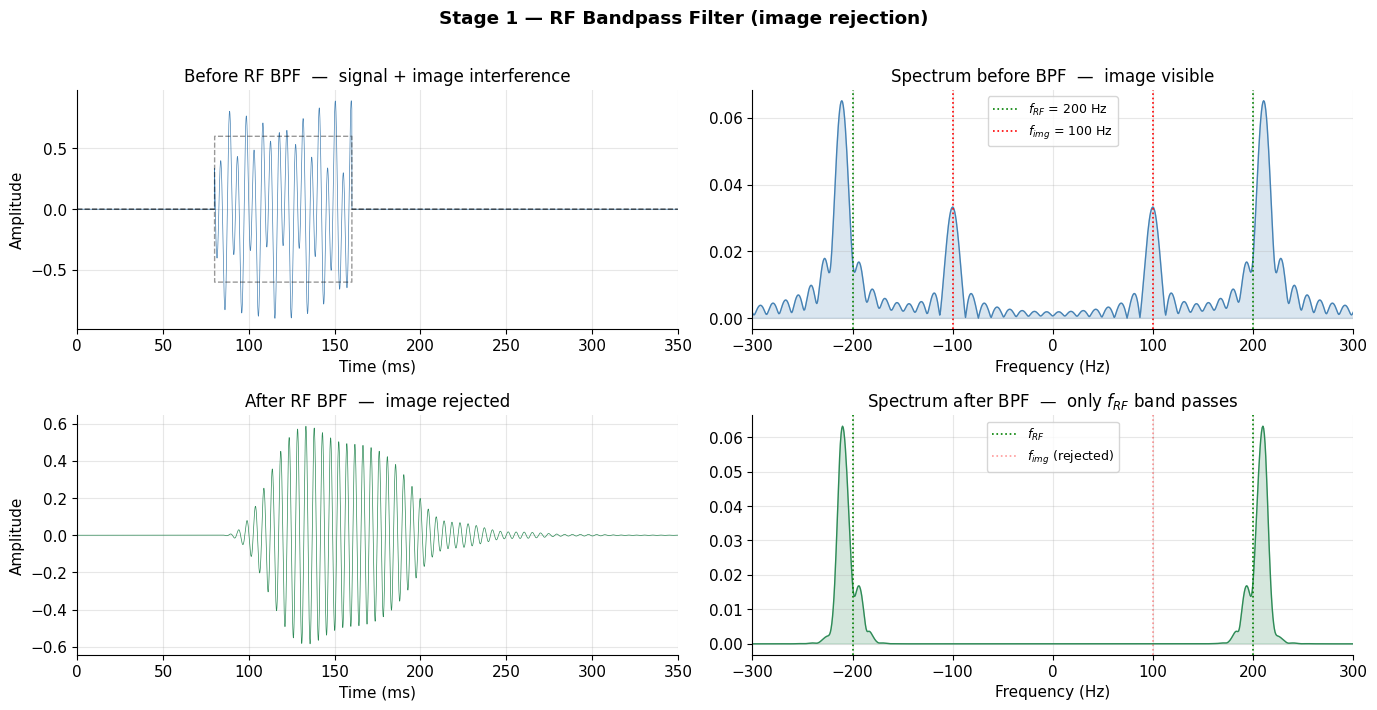

Signal type: REAL | CONTINUOUS | BANDPASS at ±f_RF (cleaned)


In [3]:
# ── Stage 1: RF Bandpass Filter ──
# Design BPF around f_rf with bandwidth ~2*B_pulse
fs_sim = 1.0 / dt_c  # simulation sampling rate
bpf_lo = (f_rf - B_pulse) / (fs_sim / 2)
bpf_hi = (f_rf + B_pulse) / (fs_sim / 2)
sos_rf = butter(4, [bpf_lo, bpf_hi], btype='band', output='sos')

s_after_bpf = sosfilt(sos_rf, s_rf)

# Also add image frequency interference to show rejection
f_img = f_lo - f_if  # image frequency
s_image = 0.3 * np.cos(2 * np.pi * f_img * t_c) * (pulse_mask).astype(float)
s_rf_with_image = s_rf + s_image
s_bpf_demo = sosfilt(sos_rf, s_rf_with_image)

freq_before, mag_before = spectrum_twosided(s_rf_with_image, t_c)
freq_after, mag_after   = spectrum_twosided(s_bpf_demo, t_c)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# Time domain before
axes[0,0].plot(t_c*1e3, s_rf_with_image, 'steelblue', lw=0.5)
axes[0,0].plot(t_c*1e3, envelope, 'k--', lw=1, alpha=0.4)
axes[0,0].plot(t_c*1e3, -envelope, 'k--', lw=1, alpha=0.4)
axes[0,0].set_title('Before RF BPF  —  signal + image interference')
axes[0,0].set_xlabel('Time (ms)'); axes[0,0].set_ylabel('Amplitude')
axes[0,0].set_xlim(0, dur*1e3)

# Spectrum before
axes[0,1].fill_between(freq_before, mag_before, alpha=0.2, color='steelblue')
axes[0,1].plot(freq_before, mag_before, 'steelblue', lw=1)
axes[0,1].axvline(f_rf, color='green', ls=':', lw=1.2, label=f'$f_{{RF}}$ = {f_rf:.0f} Hz')
axes[0,1].axvline(f_img, color='red', ls=':', lw=1.2, label=f'$f_{{img}}$ = {f_img:.0f} Hz')
axes[0,1].axvline(-f_rf, color='green', ls=':', lw=1.2)
axes[0,1].axvline(-f_img, color='red', ls=':', lw=1.2)
axes[0,1].set_xlim(-300, 300)
axes[0,1].set_title('Spectrum before BPF  —  image visible')
axes[0,1].set_xlabel('Frequency (Hz)'); axes[0,1].legend(fontsize=9)

# Time domain after
axes[1,0].plot(t_c*1e3, s_bpf_demo, 'seagreen', lw=0.5)
axes[1,0].set_title('After RF BPF  —  image rejected')
axes[1,0].set_xlabel('Time (ms)'); axes[1,0].set_ylabel('Amplitude')
axes[1,0].set_xlim(0, dur*1e3)

# Spectrum after
axes[1,1].fill_between(freq_after, mag_after, alpha=0.2, color='seagreen')
axes[1,1].plot(freq_after, mag_after, 'seagreen', lw=1)
axes[1,1].axvline(f_rf, color='green', ls=':', lw=1.2, label=f'$f_{{RF}}$')
axes[1,1].axvline(f_img, color='red', ls=':', lw=1.2, alpha=0.4, label=f'$f_{{img}}$ (rejected)')
axes[1,1].axvline(-f_rf, color='green', ls=':', lw=1.2)
axes[1,1].set_xlim(-300, 300)
axes[1,1].set_title('Spectrum after BPF  —  only $f_{RF}$ band passes')
axes[1,1].set_xlabel('Frequency (Hz)'); axes[1,1].legend(fontsize=9)

plt.suptitle('Stage 1 — RF Bandpass Filter (image rejection)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("Signal type: REAL | CONTINUOUS | BANDPASS at ±f_RF (cleaned)")

## Stage 2 — LNA (Low Noise Amplifier)

The LNA boosts the weak received signal by gain $G$ while adding minimal noise. In our simulation we model it as a simple gain stage:

$$s_{LNA}(t) = G \cdot s_{BPF}(t)$$

The **noise figure** (NF) of the LNA dominates the overall receiver noise figure (Friis formula), so it is placed as early as possible in the chain. The signal remains real, continuous, and bandpass — only its amplitude changes.

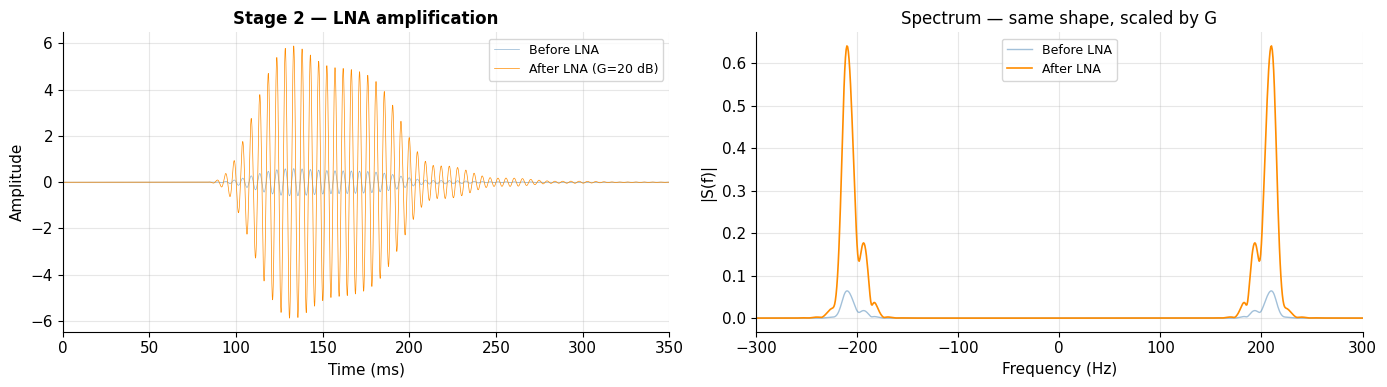

Signal type: REAL | CONTINUOUS | BANDPASS at ±f_RF (amplified)


In [4]:
# ── Stage 2: LNA ──
G_lna = 10.0  # linear gain (20 dB)
s_lna = G_lna * s_after_bpf

freq_lna, mag_lna = spectrum_twosided(s_lna, t_c)
freq_bpf, mag_bpf = spectrum_twosided(s_after_bpf, t_c)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(t_c*1e3, s_after_bpf, 'steelblue', lw=0.5, alpha=0.6, label='Before LNA')
ax1.plot(t_c*1e3, s_lna, 'darkorange', lw=0.5, label=f'After LNA (G={20*np.log10(G_lna):.0f} dB)')
ax1.set_xlabel('Time (ms)'); ax1.set_ylabel('Amplitude')
ax1.set_title('Stage 2 — LNA amplification', fontweight='bold')
ax1.legend(fontsize=9); ax1.set_xlim(0, dur*1e3)

ax2.plot(freq_bpf, mag_bpf, 'steelblue', lw=1, alpha=0.5, label='Before LNA')
ax2.plot(freq_lna, mag_lna, 'darkorange', lw=1.2, label='After LNA')
ax2.set_xlabel('Frequency (Hz)'); ax2.set_ylabel('|S(f)|')
ax2.set_title('Spectrum — same shape, scaled by G')
ax2.set_xlim(-300, 300); ax2.legend(fontsize=9)

plt.tight_layout(); plt.show()
print("Signal type: REAL | CONTINUOUS | BANDPASS at ±f_RF (amplified)")

## Stage 3 — Mixer (Down-conversion to IF)

The mixer multiplies the RF signal by the local oscillator (LO):

$$s_{mix}(t) = s_{LNA}(t) \cdot \cos(2\pi f_{LO}\, t)$$

Using the product-to-sum identity $\cos\alpha\cos\beta = \tfrac{1}{2}[\cos(\alpha-\beta) + \cos(\alpha+\beta)]$:

$$s_{mix}(t) = \frac{1}{2}\left[\underbrace{\cos(2\pi f_{IF}\, t + \phi)}_{\text{IF component (desired)}} + \underbrace{\cos(2\pi (f_{RF}+f_{LO})\, t + \phi)}_{\text{sum frequency (rejected by IF BPF)}}\right]$$

The mixer produces **two** frequency components:
- **Difference**: $f_{RF} - f_{LO} = f_{IF}$ → **desired** IF signal
- **Sum**: $f_{RF} + f_{LO}$ → far above IF, easily filtered out

The signal is still **real and continuous**, but now centered at the much lower $f_{IF}$ (plus a high-frequency sum product to be removed).

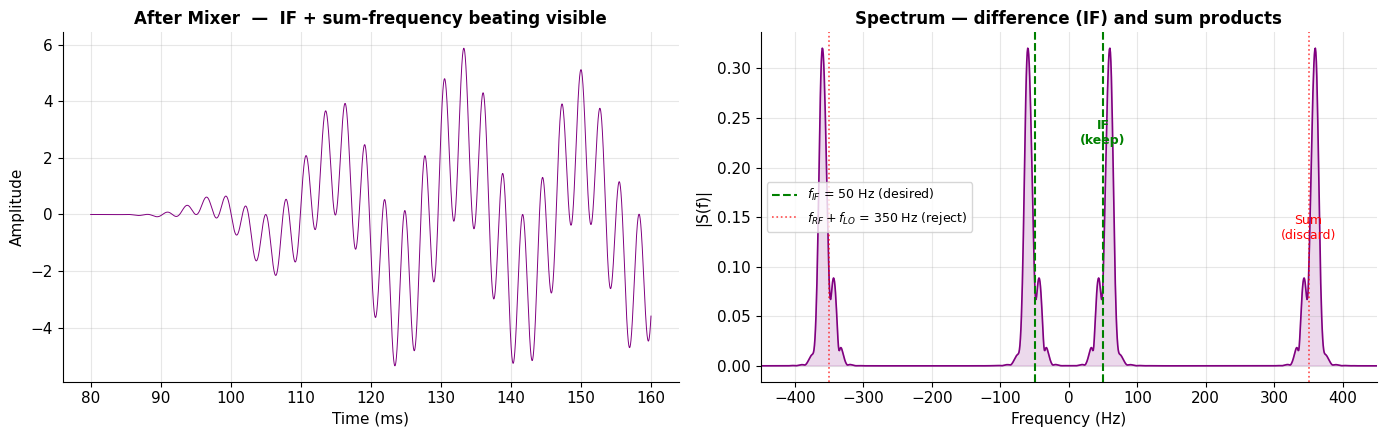

Signal type: REAL | CONTINUOUS | contains IF + sum frequency


In [5]:
# ── Stage 3: Mixer (RF → IF) ──
lo_signal = np.cos(2 * np.pi * f_lo * t_c)
s_mixed = s_lna * lo_signal  # multiplication = frequency translation

freq_mix, mag_mix = spectrum_twosided(s_mixed, t_c)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Time domain — zoomed to see both IF oscillation and sum-frequency ripple
zoom = (t_c >= 0.08) & (t_c <= 0.16)
ax1.plot(t_c[zoom]*1e3, s_mixed[zoom], 'purple', lw=0.7)
ax1.set_xlabel('Time (ms)'); ax1.set_ylabel('Amplitude')
ax1.set_title('After Mixer  —  IF + sum-frequency beating visible', fontweight='bold')

# Spectrum — show both IF and sum components
ax2.fill_between(freq_mix, mag_mix, alpha=0.15, color='purple')
ax2.plot(freq_mix, mag_mix, 'purple', lw=1.2)
ax2.axvline(f_if, color='green', ls='--', lw=1.5, label=f'$f_{{IF}}$ = {f_if:.0f} Hz (desired)')
ax2.axvline(-f_if, color='green', ls='--', lw=1.5)
ax2.axvline(f_rf + f_lo, color='red', ls=':', lw=1.2, alpha=0.7,
            label=f'$f_{{RF}}+f_{{LO}}$ = {f_rf+f_lo:.0f} Hz (reject)')
ax2.axvline(-(f_rf + f_lo), color='red', ls=':', lw=1.2, alpha=0.7)
ax2.set_xlabel('Frequency (Hz)'); ax2.set_ylabel('|S(f)|')
ax2.set_title('Spectrum — difference (IF) and sum products', fontweight='bold')
ax2.set_xlim(-450, 450)
ax2.legend(fontsize=9)
ax2.annotate('IF\n(keep)', xy=(f_if, mag_mix.max()*0.7), fontsize=9,
             color='green', ha='center', fontweight='bold')
ax2.annotate('Sum\n(discard)', xy=(f_rf+f_lo, mag_mix.max()*0.4), fontsize=9,
             color='red', ha='center')

plt.tight_layout(); plt.show()
print("Signal type: REAL | CONTINUOUS | contains IF + sum frequency")

## Stage 4 — IF Bandpass Filter

The IF BPF selects the desired IF component and rejects the sum-frequency product:

$$H_{IF}(f): \text{passband centered at } f_{IF}, \text{ bandwidth } \approx B_{pulse}$$

After this stage the signal is a clean **real, continuous, bandpass** waveform at IF — ready for IQ demodulation.

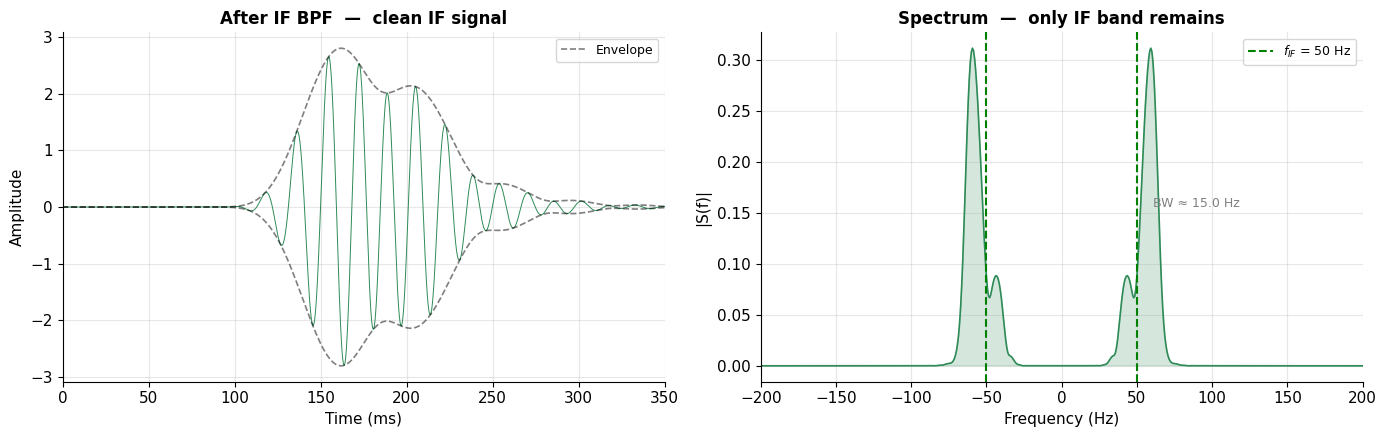

Signal type: REAL | CONTINUOUS | BANDPASS at ±f_IF


In [6]:
# ── Stage 4: IF Bandpass Filter ──
bpf_if_lo = (f_if - B_pulse) / (fs_sim / 2)
bpf_if_hi = (f_if + B_pulse) / (fs_sim / 2)
sos_if = butter(4, [bpf_if_lo, bpf_if_hi], btype='band', output='sos')

s_if = sosfilt(sos_if, s_mixed)

freq_if, mag_if = spectrum_twosided(s_if, t_c)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Time domain
ax1.plot(t_c*1e3, s_if, 'seagreen', lw=0.7)
env_if = np.abs(s_if)
from scipy.signal import hilbert
env_if = np.abs(hilbert(s_if))
ax1.plot(t_c*1e3, env_if, 'k--', lw=1.2, alpha=0.5, label='Envelope')
ax1.plot(t_c*1e3, -env_if, 'k--', lw=1.2, alpha=0.5)
ax1.set_xlabel('Time (ms)'); ax1.set_ylabel('Amplitude')
ax1.set_title('After IF BPF  —  clean IF signal', fontweight='bold')
ax1.set_xlim(0, dur*1e3); ax1.legend(fontsize=9)

# Spectrum
ax2.fill_between(freq_if, mag_if, alpha=0.2, color='seagreen')
ax2.plot(freq_if, mag_if, 'seagreen', lw=1.2)
ax2.axvline(f_if, color='green', ls='--', lw=1.5, label=f'$f_{{IF}}$ = {f_if:.0f} Hz')
ax2.axvline(-f_if, color='green', ls='--', lw=1.5)
ax2.set_xlabel('Frequency (Hz)'); ax2.set_ylabel('|S(f)|')
ax2.set_title('Spectrum  —  only IF band remains', fontweight='bold')
ax2.set_xlim(-200, 200); ax2.legend(fontsize=9)
ax2.annotate(f'BW ≈ {B_pulse} Hz', xy=(f_if + B_pulse/2 + 3, mag_if.max()*0.5),
             fontsize=9, color='gray')

plt.tight_layout(); plt.show()
print("Signal type: REAL | CONTINUOUS | BANDPASS at ±f_IF")

## Stage 5 — Analog Quadrature Demodulator (IQ Extraction at IF)

The IF signal is split into two paths and multiplied by quadrature LO signals:

$$I_{raw}(t) = s_{IF}(t) \cdot 2\cos(2\pi f_{IF}\, t) = \underbrace{I_{BB}(t)}_{\text{baseband}} + \underbrace{\text{component at } 2f_{IF}}_{\text{filtered out}}$$

$$Q_{raw}(t) = s_{IF}(t) \cdot (-2\sin(2\pi f_{IF}\, t)) = \underbrace{Q_{BB}(t)}_{\text{baseband}} + \underbrace{\text{component at } 2f_{IF}}_{\text{filtered out}}$$

The factor of 2 compensates the $1/2$ from the product-to-sum formula. After low-pass filtering to remove the $2f_{IF}$ terms, we obtain the **real-valued, continuous, baseband** I and Q signals.

Together they form the **complex baseband** signal:

$$s_{BB}(t) = I(t) + j\,Q(t)$$

whose spectrum is **single-sided** (no conjugate symmetry!) — positive and negative frequencies carry different information (e.g. positive vs. negative Doppler).

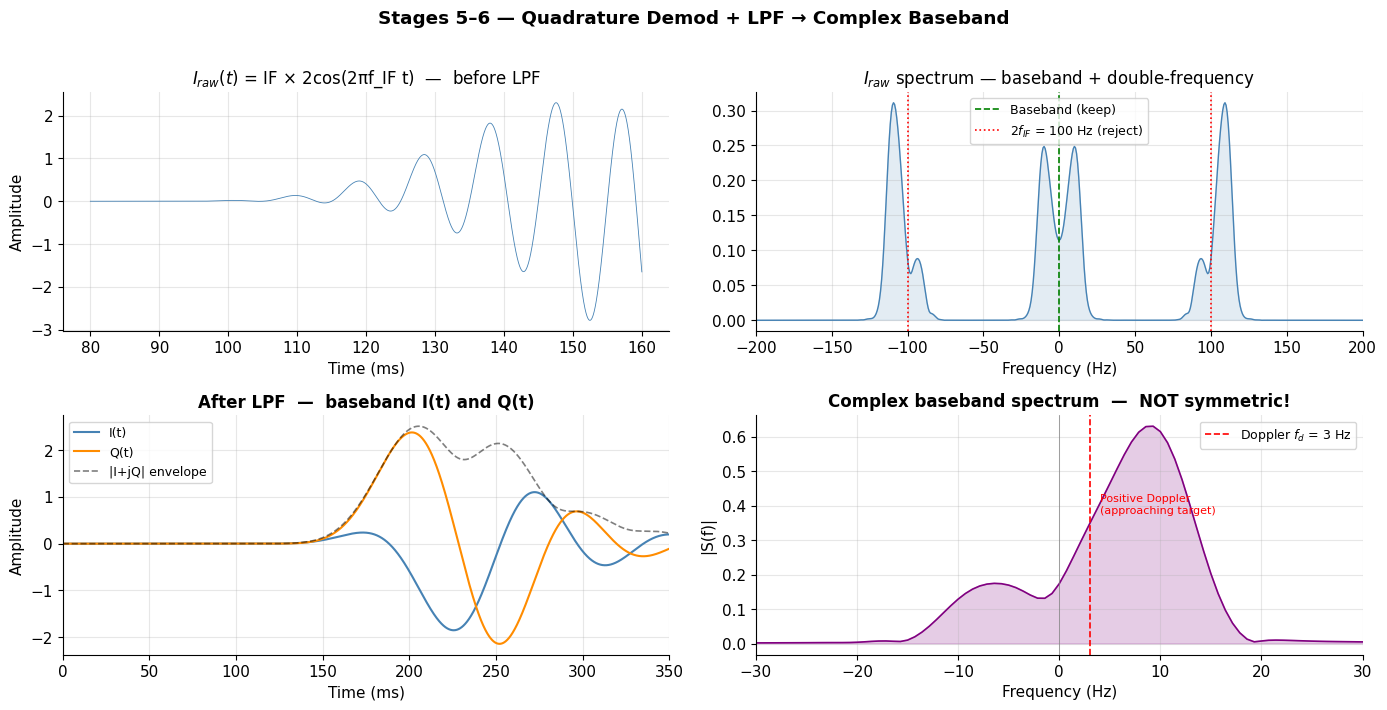

Signal type: COMPLEX | CONTINUOUS | BASEBAND (centered at DC)


In [7]:
# ── Stage 5: Quadrature Demodulator at IF ──
# Multiply by cos and -sin at f_IF
I_raw = s_if * 2 * np.cos(2 * np.pi * f_if * t_c)
Q_raw = s_if * (-2) * np.sin(2 * np.pi * f_if * t_c)

# Show raw (before LPF) — contains baseband + 2*f_IF component
freq_Iraw, mag_Iraw = spectrum_twosided(I_raw, t_c)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# I_raw time domain
zoom_iq = (t_c >= 0.08) & (t_c <= 0.16)
axes[0,0].plot(t_c[zoom_iq]*1e3, I_raw[zoom_iq], 'steelblue', lw=0.6)
axes[0,0].set_title('$I_{raw}(t)$ = IF × 2cos(2πf_IF t)  —  before LPF')
axes[0,0].set_xlabel('Time (ms)'); axes[0,0].set_ylabel('Amplitude')

# I_raw spectrum
axes[0,1].fill_between(freq_Iraw, mag_Iraw, alpha=0.15, color='steelblue')
axes[0,1].plot(freq_Iraw, mag_Iraw, 'steelblue', lw=1)
axes[0,1].axvline(0, color='green', ls='--', lw=1.2, label='Baseband (keep)')
axes[0,1].axvline(2*f_if, color='red', ls=':', lw=1.2, label=f'$2f_{{IF}}$ = {2*f_if:.0f} Hz (reject)')
axes[0,1].axvline(-2*f_if, color='red', ls=':', lw=1.2)
axes[0,1].set_xlim(-200, 200); axes[0,1].legend(fontsize=9)
axes[0,1].set_title('$I_{raw}$ spectrum — baseband + double-frequency')
axes[0,1].set_xlabel('Frequency (Hz)')

# ── Stage 6: Low-Pass Filter → clean I and Q ──
lpf_cut = B_pulse / (fs_sim / 2)
sos_lpf = butter(6, lpf_cut, btype='low', output='sos')

I_bb = sosfilt(sos_lpf, I_raw)
Q_bb = sosfilt(sos_lpf, Q_raw)
s_bb_complex = I_bb + 1j * Q_bb  # complex baseband

# I,Q baseband time domain
axes[1,0].plot(t_c*1e3, I_bb, 'steelblue', lw=1.5, label='I(t)')
axes[1,0].plot(t_c*1e3, Q_bb, 'darkorange', lw=1.5, label='Q(t)')
axes[1,0].plot(t_c*1e3, np.abs(s_bb_complex), 'k--', lw=1.2, alpha=0.5, label='|I+jQ| envelope')
axes[1,0].set_title('After LPF  —  baseband I(t) and Q(t)', fontweight='bold')
axes[1,0].set_xlabel('Time (ms)'); axes[1,0].set_ylabel('Amplitude')
axes[1,0].legend(fontsize=9); axes[1,0].set_xlim(0, dur*1e3)

# Complex baseband spectrum (two-sided) — NOT symmetric!
freq_bb, mag_bb = complex_spectrum_twosided(s_bb_complex, t_c)
axes[1,1].fill_between(freq_bb, mag_bb, alpha=0.2, color='purple')
axes[1,1].plot(freq_bb, mag_bb, 'purple', lw=1.2)
axes[1,1].axvline(0, color='gray', ls='-', lw=0.5)
axes[1,1].axvline(f_d, color='red', ls='--', lw=1.2, label=f'Doppler $f_d$ = {f_d:.0f} Hz')
axes[1,1].set_title('Complex baseband spectrum  —  NOT symmetric!', fontweight='bold')
axes[1,1].set_xlabel('Frequency (Hz)'); axes[1,1].set_ylabel('|S(f)|')
axes[1,1].set_xlim(-30, 30); axes[1,1].legend(fontsize=9)
axes[1,1].annotate('Positive Doppler\n(approaching target)', xy=(f_d+1, mag_bb.max()*0.6),
                   fontsize=8, color='red')

plt.suptitle('Stages 5–6 — Quadrature Demod + LPF → Complex Baseband', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()
print("Signal type: COMPLEX | CONTINUOUS | BASEBAND (centered at DC)")

## Stage 7 — ADC (Analog-to-Digital Conversion)

Two ADCs sample I(t) and Q(t) independently at rate $f_s$. The Nyquist requirement for baseband IQ is:

$$f_s \geq B_{pulse}$$

Note: only $B_{pulse}$, **not** $2 B_{pulse}$, because I and Q together form a complex signal whose bandwidth extends from $-B/2$ to $+B/2$. A complex signal sampled at $f_s$ has an unambiguous bandwidth of $f_s$ (not $f_s/2$ like a real signal).

After sampling, the signal becomes **complex, discrete, baseband**:

$$s_{BB}[n] = I[n] + j\,Q[n], \qquad n = 0, 1, 2, \ldots$$

This is the final output of the superheterodyne receiver — ready for digital pulse compression, Doppler processing, and detection.

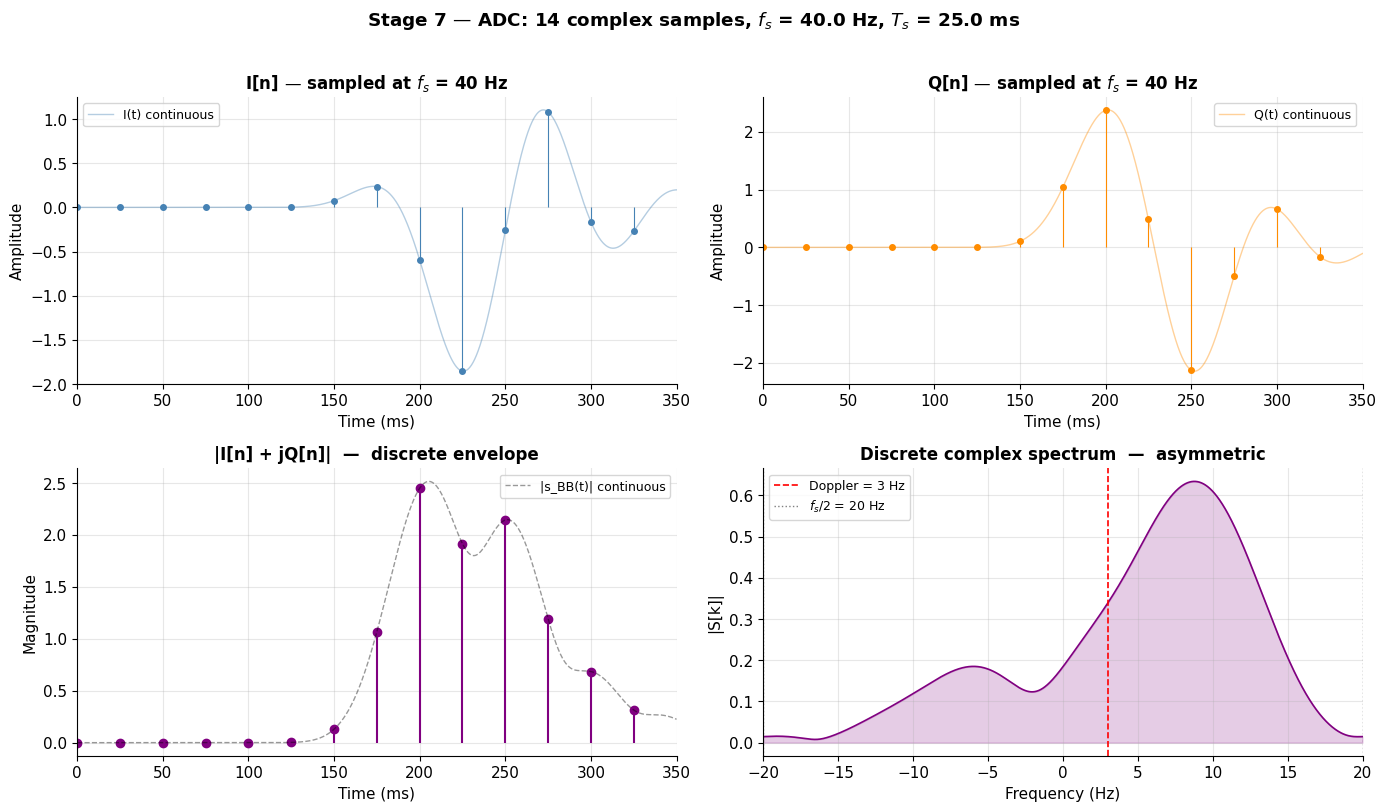

Signal type: COMPLEX | DISCRETE | BASEBAND — final output of superheterodyne receiver


In [8]:
# ── Stage 7: ADC — sample I and Q ──
fs_adc = 40.0  # sampling rate [Hz] — must be >= B_pulse
Ts_adc = 1.0 / fs_adc

# Sample the continuous I and Q
t_n = np.arange(0, dur, Ts_adc)
I_n = np.interp(t_n, t_c, I_bb)
Q_n = np.interp(t_n, t_c, Q_bb)
s_bb_discrete = I_n + 1j * Q_n

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# I channel — continuous vs discrete
axes[0,0].plot(t_c*1e3, I_bb, 'steelblue', lw=1, alpha=0.4, label='I(t) continuous')
mk, st, _ = axes[0,0].stem(t_n*1e3, I_n, linefmt='steelblue', markerfmt='o', basefmt=' ')
plt.setp(mk, ms=4, color='steelblue'); plt.setp(st, lw=0.8, color='steelblue')
axes[0,0].set_title(f'I[n] — sampled at $f_s$ = {fs_adc:.0f} Hz', fontweight='bold')
axes[0,0].set_xlabel('Time (ms)'); axes[0,0].set_ylabel('Amplitude')
axes[0,0].legend(fontsize=9); axes[0,0].set_xlim(0, dur*1e3)

# Q channel — continuous vs discrete
axes[0,1].plot(t_c*1e3, Q_bb, 'darkorange', lw=1, alpha=0.4, label='Q(t) continuous')
mk, st, _ = axes[0,1].stem(t_n*1e3, Q_n, linefmt='darkorange', markerfmt='o', basefmt=' ')
plt.setp(mk, ms=4, color='darkorange'); plt.setp(st, lw=0.8, color='darkorange')
axes[0,1].set_title(f'Q[n] — sampled at $f_s$ = {fs_adc:.0f} Hz', fontweight='bold')
axes[0,1].set_xlabel('Time (ms)'); axes[0,1].set_ylabel('Amplitude')
axes[0,1].legend(fontsize=9); axes[0,1].set_xlim(0, dur*1e3)

# Magnitude of complex discrete signal
axes[1,0].stem(t_n*1e3, np.abs(s_bb_discrete), linefmt='purple', markerfmt='o', basefmt=' ')
axes[1,0].plot(t_c*1e3, np.abs(s_bb_complex), 'k--', lw=1, alpha=0.4, label='|s_BB(t)| continuous')
axes[1,0].set_title('|I[n] + jQ[n]|  —  discrete envelope', fontweight='bold')
axes[1,0].set_xlabel('Time (ms)'); axes[1,0].set_ylabel('Magnitude')
axes[1,0].legend(fontsize=9); axes[1,0].set_xlim(0, dur*1e3)

# Discrete complex spectrum
N_disc = len(s_bb_discrete)
nfft_disc = max(N_disc * 16, 4096)
freq_disc = np.fft.fftshift(np.fft.fftfreq(nfft_disc, Ts_adc))
mag_disc  = np.fft.fftshift(np.abs(np.fft.fft(s_bb_discrete, n=nfft_disc))) / N_disc

axes[1,1].fill_between(freq_disc, mag_disc, alpha=0.2, color='purple')
axes[1,1].plot(freq_disc, mag_disc, 'purple', lw=1.2)
axes[1,1].axvline(f_d, color='red', ls='--', lw=1.2, label=f'Doppler = {f_d:.0f} Hz')
axes[1,1].axvline(fs_adc/2, color='gray', ls=':', lw=1, label=f'$f_s/2$ = {fs_adc/2:.0f} Hz')
axes[1,1].axvline(-fs_adc/2, color='gray', ls=':', lw=1)
axes[1,1].set_title('Discrete complex spectrum  —  asymmetric', fontweight='bold')
axes[1,1].set_xlabel('Frequency (Hz)'); axes[1,1].set_ylabel('|S[k]|')
axes[1,1].set_xlim(-fs_adc/2, fs_adc/2); axes[1,1].legend(fontsize=9)

plt.suptitle(f'Stage 7 — ADC: {N_disc} complex samples, $f_s$ = {fs_adc} Hz, $T_s$ = {Ts_adc*1e3:.1f} ms',
             fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()
print("Signal type: COMPLEX | DISCRETE | BASEBAND — final output of superheterodyne receiver")

## Superheterodyne — Full Chain Summary

```
Signal at each stage:

  Antenna ──► RF BPF ──► LNA ──► Mixer(×LO) ──► IF BPF ──► Quad Demod ──► LPF ──► ADC
  ─────────────────────────────────────────────────────────────────────────────────────
  REAL        REAL       REAL      REAL           REAL       REAL→2ch      REAL×2    COMPLEX
  CONT.       CONT.      CONT.     CONT.          CONT.      CONT.        CONT.     DISCRETE
  BANDPASS    BANDPASS   BANDPASS  IF+sum         BANDPASS   BB+2f_IF     BASEBAND  BASEBAND
  ±f_RF       ±f_RF      ±f_RF     ±f_IF,±f_sum   ±f_IF      ±B/2        ±B/2      ±B/2
```

**Pros**: Excellent selectivity (narrow IF filters available), mature technology, good image rejection with RF preselect filter.

**Cons**: Requires two matched ADCs, analog I/Q imbalance (gain and phase mismatch between channels), more analog components.

---

# Architecture 2 — Digital IF Receiver

Move the ADC **before** IQ demodulation: digitize the real IF signal directly, then extract I/Q in the digital domain using a **Digital Down-Converter (DDC)**.

```
Antenna → RF BPF → LNA → Mixer(×LO) → IF BPF → ADC → ×e^{-j2πf_IF nTs} → Digital LPF → Decimate → I[n]+jQ[n]
```

**Key advantage**: IQ extraction is digital → **no analog I/Q imbalance**. Perfect 90° phase shift is trivial in DSP.

**Key cost**: ADC must sample at $f_s \geq 2(f_{IF} + B/2)$ — much faster than the baseband-only ADC of Architecture 1.

## Digital IF — Step 1: ADC at IF

The IF signal is sampled directly. Since the IF signal is **real** and bandpass, the ADC rate must satisfy:

$$f_s \geq 2\left(f_{IF} + \frac{B}{2}\right)$$

to avoid aliasing the upper edge of the IF band. The sampled signal is **real, discrete, bandpass** — it still oscillates at $f_{IF}$.

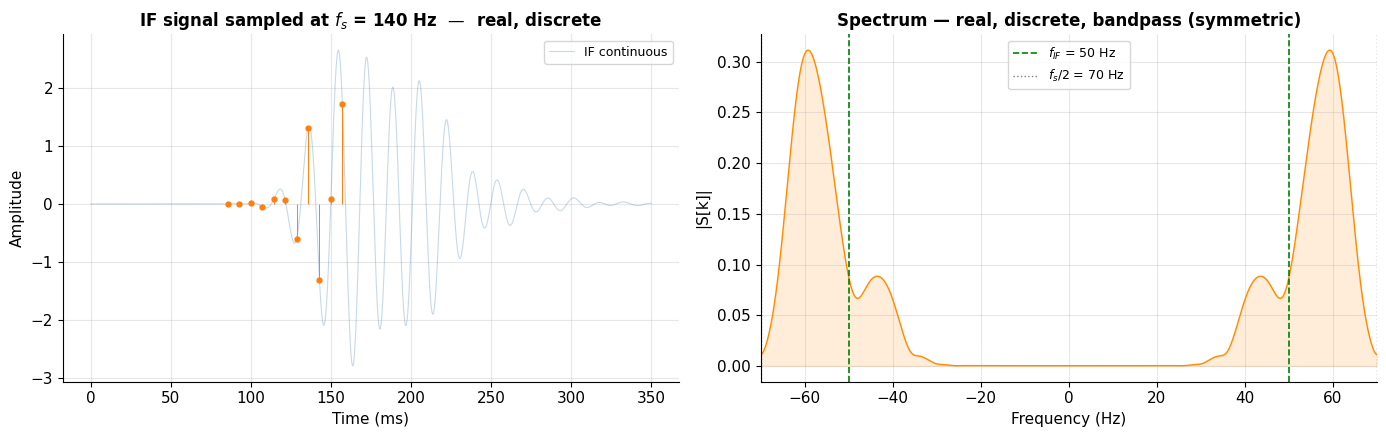

Signal type: REAL | DISCRETE | BANDPASS at ±f_IF
ADC: 49 samples, fs = 140.0 Hz > 2*(f_IF + B/2) = 115 Hz ✓


In [9]:
# ── Architecture 2: Digital IF Receiver ──
# Step 1: ADC samples the real IF signal
fs_if_adc = 140.0  # must be > 2*(f_if + B/2) = 2*(50+7.5) = 115 Hz
Ts_if_adc = 1.0 / fs_if_adc

t_if_n = np.arange(0, dur, Ts_if_adc)
s_if_sampled = np.interp(t_if_n, t_c, s_if)  # real, discrete, at IF

# Spectrum of sampled real IF signal
N_if = len(s_if_sampled)
nfft_if = max(N_if * 8, 4096)
freq_if_d = np.fft.fftshift(np.fft.fftfreq(nfft_if, Ts_if_adc))
mag_if_d  = np.fft.fftshift(np.abs(np.fft.fft(s_if_sampled, n=nfft_if))) / N_if

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Time domain — stem plot (discrete)
zoom_d = (t_if_n >= 0.08) & (t_if_n <= 0.16)
ax1.plot(t_c*1e3, s_if, 'steelblue', lw=0.8, alpha=0.3, label='IF continuous')
mk, st, _ = ax1.stem(t_if_n[zoom_d]*1e3, s_if_sampled[zoom_d],
                      linefmt='C1-', markerfmt='C1o', basefmt=' ')
plt.setp(mk, ms=3.5); plt.setp(st, lw=0.7)
ax1.set_xlabel('Time (ms)'); ax1.set_ylabel('Amplitude')
ax1.set_title(f'IF signal sampled at $f_s$ = {fs_if_adc:.0f} Hz  —  real, discrete', fontweight='bold')
ax1.legend(fontsize=9)

# Spectrum — symmetric (real signal), shows spectral replicas
ax2.fill_between(freq_if_d, mag_if_d, alpha=0.15, color='darkorange')
ax2.plot(freq_if_d, mag_if_d, 'darkorange', lw=1)
ax2.axvline(f_if, color='green', ls='--', lw=1.2, label=f'$f_{{IF}}$ = {f_if:.0f} Hz')
ax2.axvline(-f_if, color='green', ls='--', lw=1.2)
ax2.axvline(fs_if_adc/2, color='gray', ls=':', lw=1, label=f'$f_s/2$ = {fs_if_adc/2:.0f} Hz')
ax2.axvline(-fs_if_adc/2, color='gray', ls=':', lw=1)
ax2.set_xlabel('Frequency (Hz)'); ax2.set_ylabel('|S[k]|')
ax2.set_title('Spectrum — real, discrete, bandpass (symmetric)', fontweight='bold')
ax2.set_xlim(-fs_if_adc/2, fs_if_adc/2)
ax2.legend(fontsize=9)

plt.tight_layout(); plt.show()
print(f"Signal type: REAL | DISCRETE | BANDPASS at ±f_IF")
print(f"ADC: {N_if} samples, fs = {fs_if_adc} Hz > 2*(f_IF + B/2) = {2*(f_if+B_pulse/2):.0f} Hz ✓")

## Digital IF — Step 2: Digital Down-Conversion (DDC)

The DDC multiplies the real discrete IF samples by a **complex exponential**:

$$s_{DDC}[n] = s_{IF}[n] \cdot e^{-j2\pi f_{IF} n T_s} = s_{IF}[n] \cdot \bigl[\cos(2\pi f_{IF} n T_s) - j\sin(2\pi f_{IF} n T_s)\bigr]$$

This simultaneously:
1. Shifts the positive-frequency component at $+f_{IF}$ down to baseband (DC)
2. Shifts the negative-frequency component at $-f_{IF}$ to $-2f_{IF}$ (to be filtered)

The result is **complex, discrete**, but still at the high IF sampling rate and contains the unwanted $-2f_{IF}$ image.

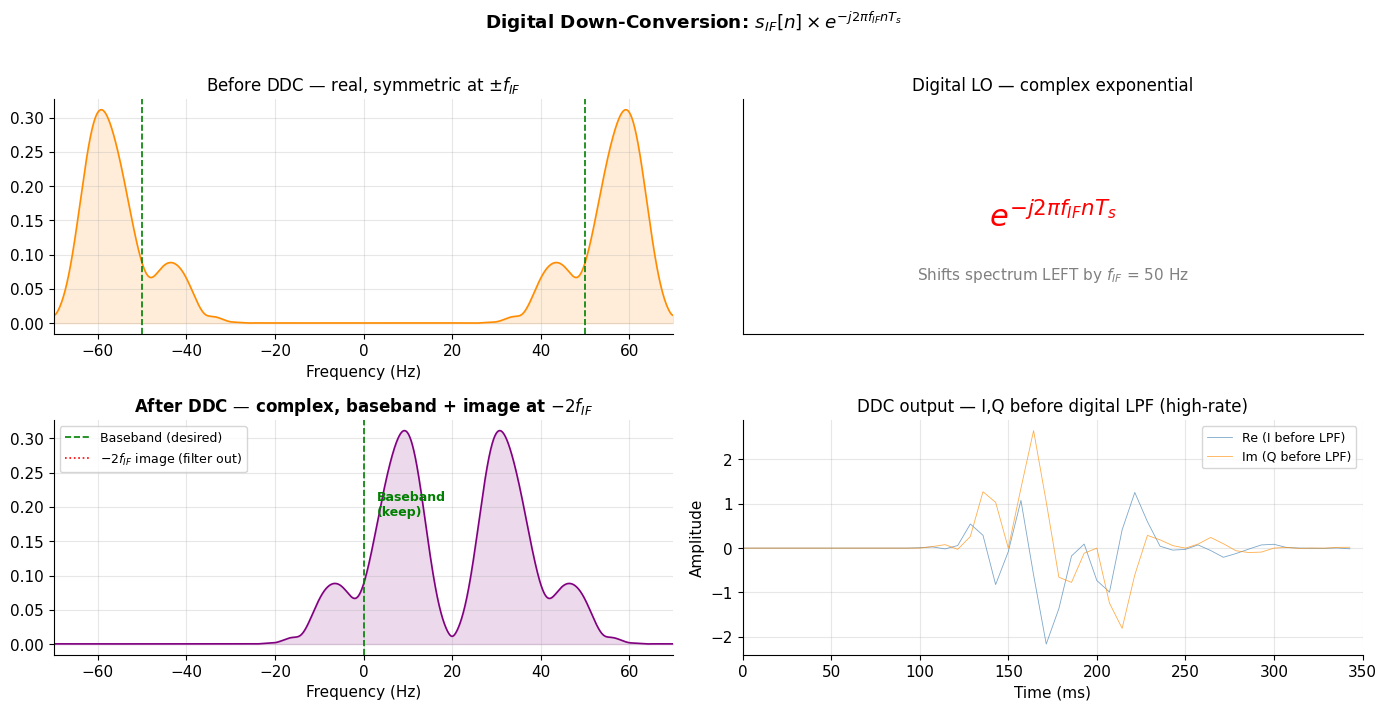

Signal type: COMPLEX | DISCRETE | BASEBAND + image at -2f_IF (high sample rate)


In [10]:
# ── Digital IF — Step 2: DDC (multiply by complex exponential) ──
n_vec = np.arange(len(s_if_sampled))
ddc_lo = np.exp(-1j * 2 * np.pi * f_if * n_vec * Ts_if_adc)
s_ddc = s_if_sampled * ddc_lo  # complex, discrete, still at high rate

# Spectrum before and after DDC
freq_ddc = np.fft.fftshift(np.fft.fftfreq(nfft_if, Ts_if_adc))
mag_ddc  = np.fft.fftshift(np.abs(np.fft.fft(s_ddc, n=nfft_if))) / N_if

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# Before DDC — real discrete spectrum (symmetric)
axes[0,0].plot(freq_if_d, mag_if_d, 'darkorange', lw=1.2)
axes[0,0].fill_between(freq_if_d, mag_if_d, alpha=0.15, color='darkorange')
axes[0,0].axvline(f_if, color='green', ls='--', lw=1.2)
axes[0,0].axvline(-f_if, color='green', ls='--', lw=1.2)
axes[0,0].set_title('Before DDC — real, symmetric at $\\pm f_{IF}$')
axes[0,0].set_xlabel('Frequency (Hz)'); axes[0,0].set_xlim(-fs_if_adc/2, fs_if_adc/2)
axes[0,0].annotate('×', xy=(0, mag_if_d.max()*1.1), fontsize=20, ha='center', color='red')

# DDC complex exponential spectrum (conceptual)
axes[0,1].annotate('$e^{-j2\\pi f_{IF} n T_s}$', xy=(0.5, 0.5), fontsize=22,
                   ha='center', va='center', xycoords='axes fraction', color='red',
                   fontweight='bold')
axes[0,1].annotate(f'Shifts spectrum LEFT by $f_{{IF}}$ = {f_if:.0f} Hz',
                   xy=(0.5, 0.25), fontsize=11, ha='center', va='center',
                   xycoords='axes fraction', color='gray')
axes[0,1].set_title('Digital LO — complex exponential')
axes[0,1].set_xticks([]); axes[0,1].set_yticks([])

# After DDC — complex spectrum (NOT symmetric)
axes[1,0].plot(freq_ddc, mag_ddc, 'purple', lw=1.2)
axes[1,0].fill_between(freq_ddc, mag_ddc, alpha=0.15, color='purple')
axes[1,0].axvline(0, color='green', ls='--', lw=1.2, label='Baseband (desired)')
axes[1,0].axvline(-2*f_if, color='red', ls=':', lw=1.2, label=f'$-2f_{{IF}}$ image (filter out)')
axes[1,0].set_title('After DDC — complex, baseband + image at $-2f_{IF}$', fontweight='bold')
axes[1,0].set_xlabel('Frequency (Hz)'); axes[1,0].set_xlim(-fs_if_adc/2, fs_if_adc/2)
axes[1,0].legend(fontsize=9)
axes[1,0].annotate('Baseband\n(keep)', xy=(3, mag_ddc.max()*0.6), fontsize=9,
                   color='green', fontweight='bold')

# Time domain of DDC output — I and Q
axes[1,1].plot(t_if_n*1e3, np.real(s_ddc), 'steelblue', lw=0.6, alpha=0.7, label='Re (I before LPF)')
axes[1,1].plot(t_if_n*1e3, np.imag(s_ddc), 'darkorange', lw=0.6, alpha=0.7, label='Im (Q before LPF)')
axes[1,1].set_title('DDC output — I,Q before digital LPF (high-rate)')
axes[1,1].set_xlabel('Time (ms)'); axes[1,1].set_ylabel('Amplitude')
axes[1,1].legend(fontsize=9); axes[1,1].set_xlim(0, dur*1e3)

plt.suptitle('Digital Down-Conversion: $s_{IF}[n] \\times e^{-j2\\pi f_{IF} nT_s}$',
             fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()
print("Signal type: COMPLEX | DISCRETE | BASEBAND + image at -2f_IF (high sample rate)")

## Digital IF — Step 3: Digital Low-Pass Filter + Decimation

A digital LPF removes the $-2f_{IF}$ image, leaving only the baseband complex signal. Since the useful bandwidth is only $B_{pulse}$, the signal is massively oversampled at the IF ADC rate. **Decimation** by factor $D$ reduces the sample rate:

$$f_{s,out} = \frac{f_{s,ADC}}{D} \geq B_{pulse}$$

This saves memory, bus bandwidth, and processing in downstream stages. The decimated output is **complex, discrete, baseband** — identical in information content to Architecture 1's output, but obtained without any analog IQ mismatch.

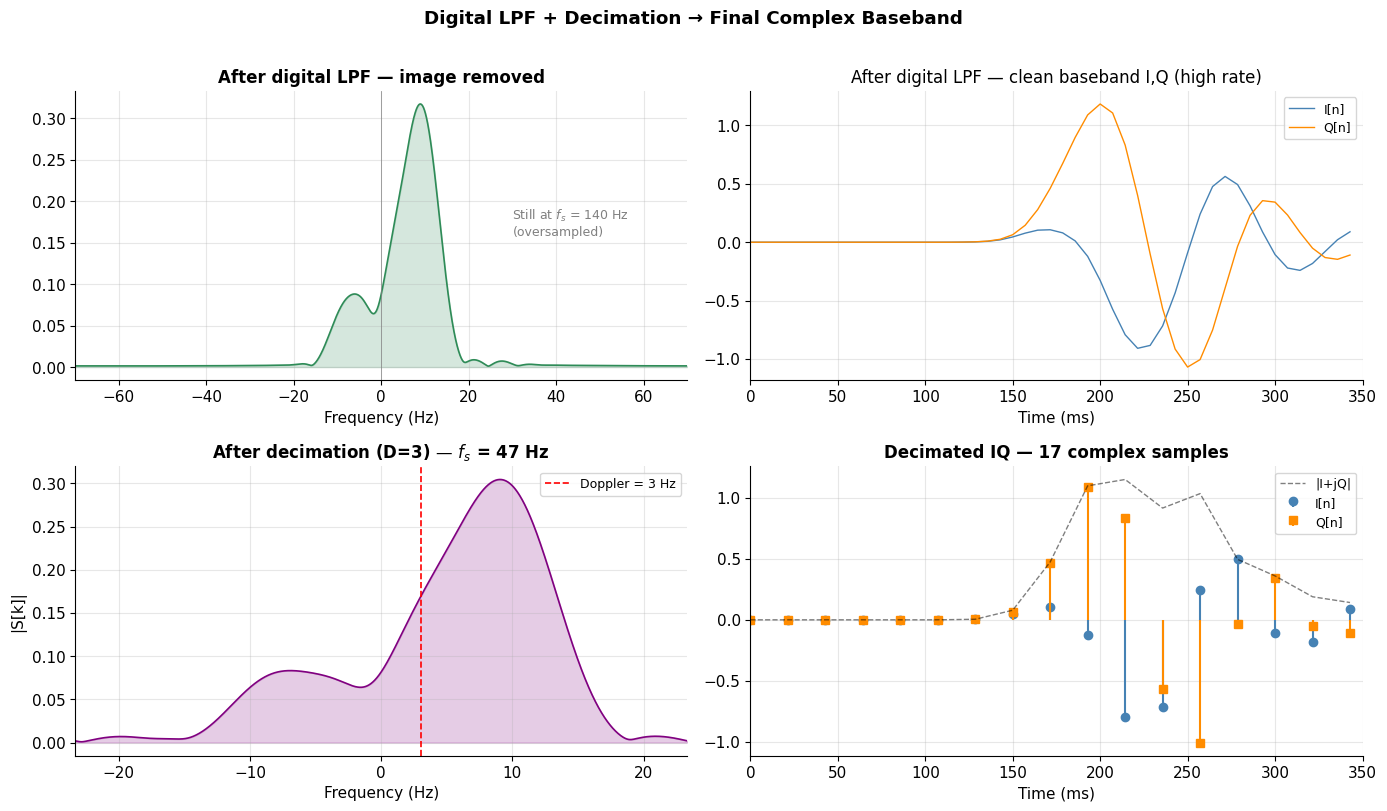

Signal type: COMPLEX | DISCRETE | BASEBAND
Decimation: 140 Hz → 47 Hz (D=3), 17 samples


In [11]:
# ── Digital IF — Step 3: Digital LPF + Decimation ──
# Digital LPF (complex-valued filtering = filter real and imag separately)
lpf_dig_cut = B_pulse / (fs_if_adc / 2)
sos_dig_lpf = butter(6, lpf_dig_cut, btype='low', output='sos')

s_ddc_filtered = sosfilt(sos_dig_lpf, np.real(s_ddc)) + 1j * sosfilt(sos_dig_lpf, np.imag(s_ddc))

# Decimation — reduce sample rate
D = int(fs_if_adc / fs_adc)  # decimate to ~same rate as Architecture 1
if D < 1: D = 1
s_ddc_dec = s_ddc_filtered[::D]
t_ddc_dec = t_if_n[::D]
fs_dec = fs_if_adc / D

# Spectra
nfft_filt = max(len(s_ddc_filtered) * 4, 4096)
freq_filt = np.fft.fftshift(np.fft.fftfreq(nfft_filt, Ts_if_adc))
mag_filt  = np.fft.fftshift(np.abs(np.fft.fft(s_ddc_filtered, n=nfft_filt))) / len(s_ddc_filtered)

N_dec = len(s_ddc_dec)
nfft_dec = max(N_dec * 16, 4096)
freq_dec_ax = np.fft.fftshift(np.fft.fftfreq(nfft_dec, 1.0/fs_dec))
mag_dec  = np.fft.fftshift(np.abs(np.fft.fft(s_ddc_dec, n=nfft_dec))) / N_dec

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# After digital LPF — spectrum
axes[0,0].plot(freq_filt, mag_filt, 'seagreen', lw=1.2)
axes[0,0].fill_between(freq_filt, mag_filt, alpha=0.2, color='seagreen')
axes[0,0].axvline(0, color='gray', ls='-', lw=0.5)
axes[0,0].set_title('After digital LPF — image removed', fontweight='bold')
axes[0,0].set_xlabel('Frequency (Hz)'); axes[0,0].set_xlim(-fs_if_adc/2, fs_if_adc/2)
axes[0,0].annotate(f'Still at $f_s$ = {fs_if_adc:.0f} Hz\n(oversampled)', xy=(30, mag_filt.max()*0.5),
                   fontsize=9, color='gray')

# After digital LPF — time domain
axes[0,1].plot(t_if_n*1e3, np.real(s_ddc_filtered), 'steelblue', lw=1, label='I[n]')
axes[0,1].plot(t_if_n*1e3, np.imag(s_ddc_filtered), 'darkorange', lw=1, label='Q[n]')
axes[0,1].set_title('After digital LPF — clean baseband I,Q (high rate)')
axes[0,1].set_xlabel('Time (ms)'); axes[0,1].legend(fontsize=9); axes[0,1].set_xlim(0, dur*1e3)

# After decimation — spectrum
axes[1,0].plot(freq_dec_ax, mag_dec, 'purple', lw=1.2)
axes[1,0].fill_between(freq_dec_ax, mag_dec, alpha=0.2, color='purple')
axes[1,0].axvline(f_d, color='red', ls='--', lw=1.2, label=f'Doppler = {f_d:.0f} Hz')
axes[1,0].set_title(f'After decimation (D={D}) — $f_s$ = {fs_dec:.0f} Hz', fontweight='bold')
axes[1,0].set_xlabel('Frequency (Hz)'); axes[1,0].set_ylabel('|S[k]|')
axes[1,0].set_xlim(-fs_dec/2, fs_dec/2); axes[1,0].legend(fontsize=9)

# After decimation — time domain
axes[1,1].stem(t_ddc_dec*1e3, np.real(s_ddc_dec), linefmt='steelblue', markerfmt='o', basefmt=' ',
               label='I[n]')
axes[1,1].stem(t_ddc_dec*1e3, np.imag(s_ddc_dec), linefmt='darkorange', markerfmt='s', basefmt=' ',
               label='Q[n]')
axes[1,1].plot(t_ddc_dec*1e3, np.abs(s_ddc_dec), 'k--', lw=1, alpha=0.5, label='|I+jQ|')
axes[1,1].set_title(f'Decimated IQ — {N_dec} complex samples', fontweight='bold')
axes[1,1].set_xlabel('Time (ms)'); axes[1,1].legend(fontsize=9); axes[1,1].set_xlim(0, dur*1e3)

plt.suptitle('Digital LPF + Decimation → Final Complex Baseband', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()
print(f"Signal type: COMPLEX | DISCRETE | BASEBAND")
print(f"Decimation: {fs_if_adc:.0f} Hz → {fs_dec:.0f} Hz (D={D}), {N_dec} samples")

## Digital IF — Full Chain Summary

```
Signal at each stage:

  Antenna ──► RF BPF ──► LNA ──► Mixer(×LO) ──► IF BPF ──► ADC ──► DDC(×e^-j) ──► Dig.LPF ──► ↓D
  ──────────────────────────────────────────────────────────────────────────────────────────────────
  REAL        REAL       REAL      REAL           REAL       REAL     COMPLEX       COMPLEX     COMPLEX
  CONT.       CONT.      CONT.     CONT.          CONT.      DISC.    DISC.         DISC.       DISC.
  BANDPASS    BANDPASS   BANDPASS  IF+sum         BANDPASS   BANDPASS  BB+image      BASEBAND    BASEBAND
  ±f_RF       ±f_RF      ±f_RF     ±f_IF          ±f_IF      ±f_IF    ±B/2,-2f_IF   ±B/2        ±B/2
                                                             (high fs) (high fs)     (high fs)   (low fs)
```

**Pros**: No analog IQ imbalance (digital mixing is perfect), flexible (DDC can be reprogrammed for different IFs), one ADC instead of two.

**Cons**: ADC must run at $\geq 2(f_{IF} + B/2)$ — requires faster, more expensive ADC. More digital processing (DDC + FIR filter + decimation).

---

# Architecture 3 — Homodyne (Direct Conversion) Receiver

Skip the IF stage entirely. Mix directly from RF to baseband using a quadrature mixer at the RF frequency:

```
Antenna → RF BPF → LNA → ┬─ ×cos(2πf_RF t) → LPF → ADC → I[n]
                          └─ ×sin(2πf_RF t) → LPF → ADC → Q[n]
```

**Key idea**: $f_{LO} = f_{RF}$ → the difference frequency is DC (baseband). No IF stage at all.

**Pros**: Simplest architecture, fewest components, no image frequency problem (IF = 0).

**Cons**: DC offset from LO self-mixing (LO leaks into mixer input), $1/f$ noise at DC, LO pulling (antenna re-radiates LO), requires very good analog IQ balance at RF frequency.

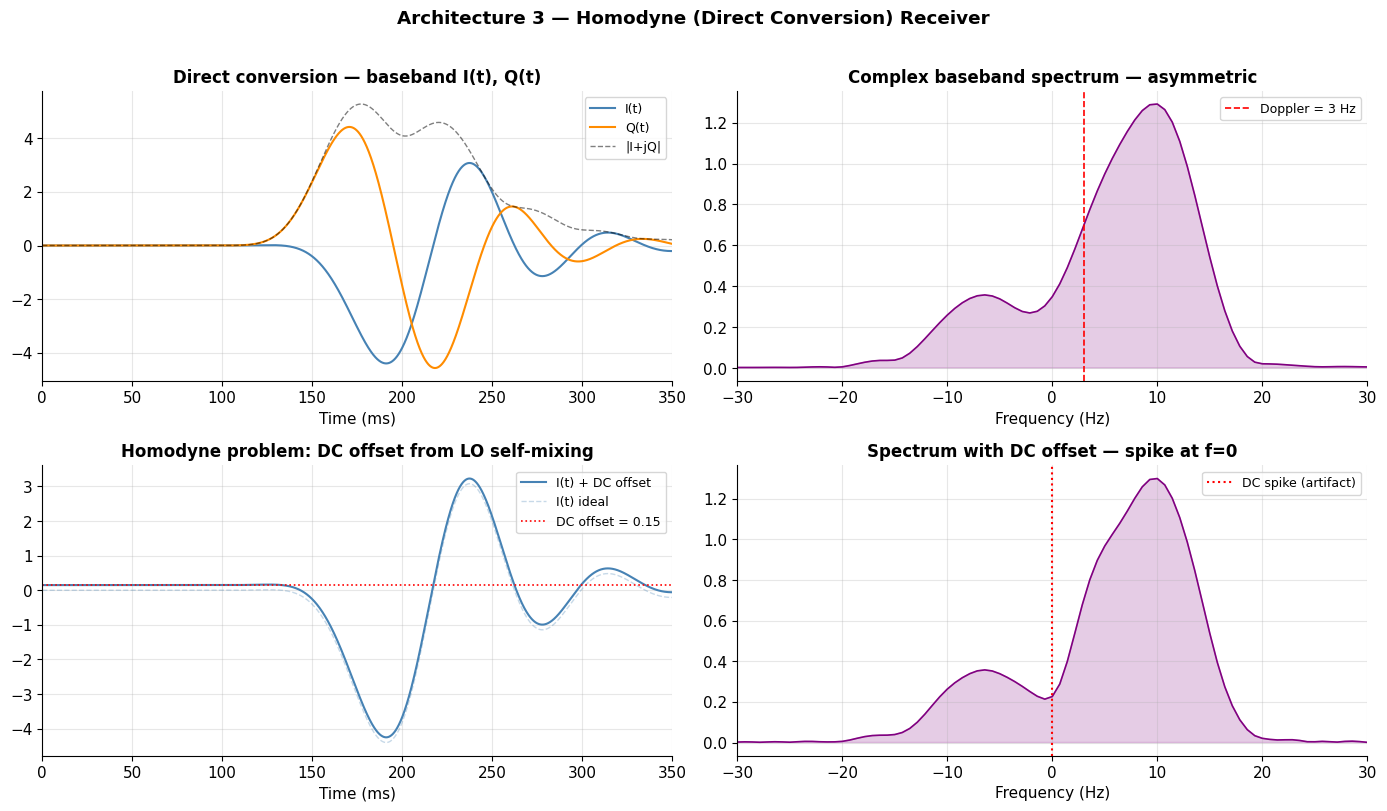

Signal type: COMPLEX | CONTINUOUS→DISCRETE | BASEBAND (with DC offset issue)


In [12]:
# ── Architecture 3: Homodyne (Direct Conversion) ──
# Mix RF signal directly to baseband with quadrature LO at f_RF
s_lna_clean = G_lna * s_after_bpf  # reuse cleaned RF signal after BPF + LNA

I_homodyne_raw = s_lna_clean * 2 * np.cos(2 * np.pi * f_rf * t_c)
Q_homodyne_raw = s_lna_clean * (-2) * np.sin(2 * np.pi * f_rf * t_c)

# LPF to extract baseband
I_homodyne = sosfilt(sos_lpf, I_homodyne_raw)
Q_homodyne = sosfilt(sos_lpf, Q_homodyne_raw)

# Add realistic DC offset (LO self-mixing artifact)
dc_offset = 0.15
I_homodyne_dc = I_homodyne + dc_offset

s_homodyne_complex = I_homodyne + 1j * Q_homodyne
s_homodyne_dc      = I_homodyne_dc + 1j * Q_homodyne

# ADC sampling
t_hom_n = np.arange(0, dur, Ts_adc)
I_hom_n = np.interp(t_hom_n, t_c, I_homodyne)
Q_hom_n = np.interp(t_hom_n, t_c, Q_homodyne)
I_hom_dc_n = np.interp(t_hom_n, t_c, I_homodyne_dc)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Continuous I,Q after LPF
axes[0,0].plot(t_c*1e3, I_homodyne, 'steelblue', lw=1.5, label='I(t)')
axes[0,0].plot(t_c*1e3, Q_homodyne, 'darkorange', lw=1.5, label='Q(t)')
axes[0,0].plot(t_c*1e3, np.abs(s_homodyne_complex), 'k--', lw=1, alpha=0.5, label='|I+jQ|')
axes[0,0].set_title('Direct conversion — baseband I(t), Q(t)', fontweight='bold')
axes[0,0].set_xlabel('Time (ms)'); axes[0,0].legend(fontsize=9); axes[0,0].set_xlim(0, dur*1e3)

# Complex spectrum
freq_hom, mag_hom = complex_spectrum_twosided(s_homodyne_complex, t_c)
axes[0,1].fill_between(freq_hom, mag_hom, alpha=0.2, color='purple')
axes[0,1].plot(freq_hom, mag_hom, 'purple', lw=1.2)
axes[0,1].axvline(f_d, color='red', ls='--', lw=1.2, label=f'Doppler = {f_d:.0f} Hz')
axes[0,1].set_title('Complex baseband spectrum — asymmetric', fontweight='bold')
axes[0,1].set_xlabel('Frequency (Hz)'); axes[0,1].set_xlim(-30, 30)
axes[0,1].legend(fontsize=9)

# DC offset problem — time domain
axes[1,0].plot(t_c*1e3, I_homodyne_dc, 'steelblue', lw=1.5, label='I(t) + DC offset')
axes[1,0].plot(t_c*1e3, I_homodyne, 'steelblue', lw=1, alpha=0.3, ls='--', label='I(t) ideal')
axes[1,0].axhline(dc_offset, color='red', ls=':', lw=1.2, label=f'DC offset = {dc_offset}')
axes[1,0].set_title('Homodyne problem: DC offset from LO self-mixing', fontweight='bold')
axes[1,0].set_xlabel('Time (ms)'); axes[1,0].legend(fontsize=9); axes[1,0].set_xlim(0, dur*1e3)

# DC offset in spectrum
freq_dc, mag_dc = complex_spectrum_twosided(s_homodyne_dc, t_c)
axes[1,1].fill_between(freq_dc, mag_dc, alpha=0.2, color='purple')
axes[1,1].plot(freq_dc, mag_dc, 'purple', lw=1.2)
axes[1,1].axvline(0, color='red', ls=':', lw=1.5, label='DC spike (artifact)')
axes[1,1].set_title('Spectrum with DC offset — spike at f=0', fontweight='bold')
axes[1,1].set_xlabel('Frequency (Hz)'); axes[1,1].set_xlim(-30, 30)
axes[1,1].legend(fontsize=9)

plt.suptitle('Architecture 3 — Homodyne (Direct Conversion) Receiver', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()
print("Signal type: COMPLEX | CONTINUOUS→DISCRETE | BASEBAND (with DC offset issue)")

## Homodyne — Full Chain Summary

```
Signal at each stage:

  Antenna ──► RF BPF ──► LNA ──► Quad Mixer(×LO at f_RF) ──► LPF ──► ADC
  ───────────────────────────────────────────────────────────────────────
  REAL        REAL       REAL      REAL→2ch                   REAL×2    COMPLEX
  CONT.       CONT.      CONT.     CONT.                      CONT.     DISCRETE
  BANDPASS    BANDPASS   BANDPASS  BB + 2f_RF                 BASEBAND  BASEBAND
  ±f_RF       ±f_RF      ±f_RF                                ±B/2      ±B/2
```

**Pros**: Fewest components, no image frequency, lowest ADC rate ($f_s \geq B$), simplest chain.

**Cons**: DC offset, $1/f$ noise, LO leakage, requires analog IQ balance at RF (very hard at GHz).

---

# The IQ Signal — Why Complex Baseband?

All three architectures produce the same output: **complex discrete baseband samples** $s[n] = I[n] + jQ[n]$. Why is the complex representation essential?

In [ ]:
# ── Why IQ? Real vs Complex baseband ──
# Demonstrate: real-only baseband loses Doppler sign

# Two targets: one approaching (+f_d), one receding (-f_d)
t_demo = np.linspace(0, 0.3, 20000)
dt_demo = t_demo[1] - t_demo[0]
pulse_demo = (t_demo >= 0.05) & (t_demo <= 0.15)

# Approaching target (positive Doppler)
s_approach = np.zeros_like(t_demo)
s_approach[pulse_demo] = np.cos(2*np.pi*(f_rf + f_d)*t_demo[pulse_demo])

# Receding target (negative Doppler)
s_recede = np.zeros_like(t_demo)
s_recede[pulse_demo] = np.cos(2*np.pi*(f_rf - f_d)*t_demo[pulse_demo])

# Demodulate both — real-only (I channel only)
I_approach = sosfilt(sos_lpf, s_approach * 2*np.cos(2*np.pi*f_rf*t_demo))
I_recede   = sosfilt(sos_lpf, s_recede   * 2*np.cos(2*np.pi*f_rf*t_demo))

# Demodulate both — complex (I + jQ)
Q_approach = sosfilt(sos_lpf, s_approach * (-2)*np.sin(2*np.pi*f_rf*t_demo))
Q_recede   = sosfilt(sos_lpf, s_recede   * (-2)*np.sin(2*np.pi*f_rf*t_demo))

iq_approach = I_approach + 1j * Q_approach
iq_recede   = I_recede   + 1j * Q_recede

# Spectra
nfft_demo = 16384
freq_real = np.fft.rfftfreq(nfft_demo, dt_demo)
freq_cplx = np.fft.fftshift(np.fft.fftfreq(nfft_demo, dt_demo))

mag_I_app = np.abs(np.fft.rfft(I_approach, n=nfft_demo)) / len(I_approach)
mag_I_rec = np.abs(np.fft.rfft(I_recede,   n=nfft_demo)) / len(I_recede)

mag_IQ_app = np.fft.fftshift(np.abs(np.fft.fft(iq_approach, n=nfft_demo))) / len(iq_approach)
mag_IQ_rec = np.fft.fftshift(np.abs(np.fft.fft(iq_recede,   n=nfft_demo))) / len(iq_recede)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real-only spectrum (one-sided) — both targets at same |f_d|
axes[0].plot(freq_real, mag_I_app, 'steelblue', lw=1.5, label='Approaching (+$f_d$)')
axes[0].plot(freq_real, mag_I_rec, 'red', lw=1.5, ls='--', label='Receding ($-f_d$)')
axes[0].axvline(f_d, color='gray', ls=':', lw=1)
axes[0].set_xlim(0, 15); axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_title('Real-only (I channel) spectrum\nBOTH targets at same frequency — AMBIGUOUS!',
                  fontweight='bold', color='red')
axes[0].legend(fontsize=10)
axes[0].annotate('Cannot distinguish\napproaching vs receding!',
                xy=(f_d+1, mag_I_app.max()*0.6), fontsize=10, color='red', fontweight='bold')

# Complex IQ spectrum (two-sided) — targets separated!
axes[1].plot(freq_cplx, mag_IQ_app, 'steelblue', lw=1.5, label='Approaching → +$f_d$')
axes[1].plot(freq_cplx, mag_IQ_rec, 'red', lw=1.5, ls='--', label='Receding → $-f_d$')
axes[1].axvline(f_d, color='steelblue', ls=':', lw=1)
axes[1].axvline(-f_d, color='red', ls=':', lw=1)
axes[1].axvline(0, color='gray', ls='-', lw=0.5)
axes[1].set_xlim(-15, 15); axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_title('Complex IQ spectrum\nTargets SEPARATED by Doppler sign — UNAMBIGUOUS!',
                  fontweight='bold', color='green')
axes[1].legend(fontsize=10)
axes[1].annotate('Approaching', xy=(f_d+0.5, mag_IQ_app.max()*0.7),
                fontsize=9, color='steelblue', fontweight='bold')
axes[1].annotate('Receding', xy=(-f_d-5, mag_IQ_rec.max()*0.7),
                fontsize=9, color='red', fontweight='bold')

plt.suptitle('Why IQ? — Doppler sign ambiguity with real-only vs complex baseband',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## Key insight: real vs complex bandwidth

| Signal type | Spectrum symmetry | Unambiguous BW at rate $f_s$ | Nyquist condition |
|:---|:---|:---|:---|
| **Real** $x[n] \in \mathbb{R}$ | $X(-f) = X^*(f)$ — conjugate symmetric | $f_s/2$ (one-sided) | $f_s \geq 2B$ |
| **Complex** $x[n] \in \mathbb{C}$ | No symmetry constraint | $f_s$ (two-sided, $-f_s/2$ to $+f_s/2$) | $f_s \geq B$ |

A complex signal carries **twice the information** per sample compared to a real signal. This is why IQ sampling at rate $f_s = B$ captures the same bandwidth as real sampling at $f_s = 2B$.

---

# Sampling Rate Considerations

## Real bandpass sampling (Digital IF)

For a real IF signal with carrier $f_{IF}$ and bandwidth $B$:
- **Standard Nyquist**: $f_s \geq 2(f_{IF} + B/2)$ — sample everything from DC to the upper band edge
- **Bandpass (undersampling)**: if $f_s \geq 2B$ and chosen so that spectral replicas don't overlap the IF band, the signal aliases cleanly to a lower frequency — intentional, controlled aliasing

## Complex baseband sampling (after IQ demod)

For complex baseband with bandwidth $B$:
- $f_s \geq B$ is sufficient (not $2B$!)
- Unambiguous frequency range: $[-f_s/2, +f_s/2]$

## Bandpass sampling (undersampling at IF)

Instead of sampling at $f_s > 2f_{IF}$, we can deliberately undersample a bandpass signal. Valid undersampling rates must satisfy:

$$\frac{2f_{IF} + B}{m+1} \leq f_s \leq \frac{2f_{IF} - B}{m}, \qquad m = 1, 2, 3, \ldots$$

where $m$ is the aliasing zone number. The signal aliases to a lower center frequency while preserving its bandwidth.

In [ ]:
# ── Bandpass Sampling Demonstration ──
# Show three sampling regimes for the IF signal:
# 1) Oversampling (standard Nyquist): fs > 2*(f_IF + B/2)
# 2) Bandpass undersampling: fs ~ 2B, chosen carefully
# 3) Too-low sampling: aliasing corrupts the signal

fs_over   = 140.0   # standard Nyquist
fs_under  = 35.0    # bandpass sampling (m=2: valid range ~33-38 Hz)
fs_bad    = 25.0    # causes overlap

configs = [
    (fs_over,  'Oversampling ($f_s$ = 140 Hz > 2·57.5)',  '#2ca02c'),
    (fs_under, 'Bandpass sampling ($f_s$ = 35 Hz ≈ 2B)',  '#ff7f0e'),
    (fs_bad,   'Under-sampled ($f_s$ = 25 Hz) — ALIASING', '#d62728'),
]

fig, axes = plt.subplots(len(configs), 2, figsize=(14, 10))

for i, (fs_test, label, color) in enumerate(configs):
    Ts_test = 1.0 / fs_test
    t_test = np.arange(0, dur, Ts_test)
    s_test = np.interp(t_test, t_c, s_if)

    N_test = len(s_test)
    nfft_test = max(N_test * 16, 8192)
    freq_test = np.fft.fftshift(np.fft.fftfreq(nfft_test, Ts_test))
    mag_test  = np.fft.fftshift(np.abs(np.fft.fft(s_test, n=nfft_test))) / N_test

    # Time domain (zoomed)
    zoom_t = (t_test >= 0.08) & (t_test <= 0.16)
    axes[i,0].plot(t_c*1e3, s_if, 'steelblue', lw=0.6, alpha=0.3)
    mk, st, _ = axes[i,0].stem(t_test[zoom_t]*1e3, s_test[zoom_t],
                                linefmt='-', markerfmt='o', basefmt=' ')
    plt.setp(mk, ms=4, color=color); plt.setp(st, lw=0.7, color=color)
    axes[i,0].set_title(label, color=color, fontweight='bold')
    axes[i,0].set_ylabel('Amplitude')
    if i == len(configs)-1: axes[i,0].set_xlabel('Time (ms)')

    # Spectrum
    axes[i,1].fill_between(freq_test, mag_test, alpha=0.2, color=color)
    axes[i,1].plot(freq_test, mag_test, color=color, lw=1)
    axes[i,1].axvline(fs_test/2, color='gray', ls=':', lw=1, label=f'$f_s/2$ = {fs_test/2:.0f} Hz')
    axes[i,1].axvline(-fs_test/2, color='gray', ls=':', lw=1)
    axes[i,1].set_xlim(-fs_test/2 * 1.1, fs_test/2 * 1.1)
    axes[i,1].legend(fontsize=8)
    if i == len(configs)-1: axes[i,1].set_xlabel('Frequency (Hz)')

plt.suptitle('Sampling Rate Comparison — Real IF Signal at $f_{IF}$ = 50 Hz, B = 15 Hz',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

---

# Side-by-Side Comparison — All Three Architectures

The plot below compares the final complex baseband IQ output from all three receiver architectures. Despite taking very different paths, they all converge to the same information: a complex discrete baseband signal centered at DC with the Doppler shift preserved.

In [ ]:
# ── Final comparison: all three architectures output ──
# Architecture 1: s_bb_discrete (I_n + jQ_n at t_n)
# Architecture 2: s_ddc_dec (at t_ddc_dec)
# Architecture 3: homodyne (I_hom_n + jQ_hom_n at t_hom_n)

s_hom_discrete = I_hom_n + 1j * Q_hom_n

arch_data = [
    ('1. Superheterodyne\n(Analog IQ)',    t_n,       s_bb_discrete,  'steelblue'),
    ('2. Digital IF\n(DDC)',               t_ddc_dec, s_ddc_dec,      'seagreen'),
    ('3. Homodyne\n(Direct Conversion)',   t_hom_n,   s_hom_discrete, 'darkorange'),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 10))

for i, (name, t_arch, s_arch, color) in enumerate(arch_data):
    N_a = len(s_arch)
    dt_a = t_arch[1] - t_arch[0] if len(t_arch) > 1 else Ts_adc
    fs_a = 1.0 / dt_a

    # I and Q time domain
    axes[i,0].stem(t_arch*1e3, np.real(s_arch), linefmt=color, markerfmt='o', basefmt=' ')
    axes[i,0].stem(t_arch*1e3, np.imag(s_arch), linefmt='gray', markerfmt='s', basefmt=' ')
    axes[i,0].set_ylabel('Amplitude')
    axes[i,0].set_title(name, fontweight='bold', color=color, fontsize=10)
    axes[i,0].set_xlim(0, dur*1e3)
    if i == 0:
        axes[i,0].legend(handles=[
            Line2D([0],[0], color=color, marker='o', ms=4, lw=0, label='I[n]'),
            Line2D([0],[0], color='gray', marker='s', ms=4, lw=0, label='Q[n]'),
        ], fontsize=8)
    if i == 2: axes[i,0].set_xlabel('Time (ms)')

    # Magnitude
    axes[i,1].stem(t_arch*1e3, np.abs(s_arch), linefmt=color, markerfmt='o', basefmt=' ')
    axes[i,1].set_ylabel('|I+jQ|')
    axes[i,1].set_title(f'Envelope  ({N_a} samples)', fontsize=10)
    axes[i,1].set_xlim(0, dur*1e3)
    if i == 2: axes[i,1].set_xlabel('Time (ms)')

    # Complex spectrum
    nfft_a = max(N_a * 16, 4096)
    freq_a = np.fft.fftshift(np.fft.fftfreq(nfft_a, dt_a))
    mag_a  = np.fft.fftshift(np.abs(np.fft.fft(s_arch, n=nfft_a))) / N_a
    axes[i,2].fill_between(freq_a, mag_a, alpha=0.2, color=color)
    axes[i,2].plot(freq_a, mag_a, color=color, lw=1.2)
    axes[i,2].axvline(f_d, color='red', ls='--', lw=1, alpha=0.7)
    axes[i,2].axvline(0, color='gray', ls='-', lw=0.5)
    axes[i,2].set_xlim(-20, 20)
    axes[i,2].set_title(f'Complex spectrum ($f_s$ = {fs_a:.0f} Hz)', fontsize=10)
    if i == 2: axes[i,2].set_xlabel('Frequency (Hz)')

plt.suptitle('All Three Architectures → Same Complex Discrete Baseband Output',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

# Summary — Receiver Architecture Comparison

## Signal transformation through each architecture

| Stage | Superheterodyne | Digital IF | Homodyne |
|:---|:---|:---|:---|
| **Antenna** | Real, cont., bandpass $\pm f_{RF}$ | Real, cont., bandpass $\pm f_{RF}$ | Real, cont., bandpass $\pm f_{RF}$ |
| **RF BPF** | Real, cont., bandpass (cleaned) | Real, cont., bandpass (cleaned) | Real, cont., bandpass (cleaned) |
| **LNA** | Real, cont., bandpass (amplified) | Real, cont., bandpass (amplified) | Real, cont., bandpass (amplified) |
| **1st Mixer** | Real, cont., IF + sum freq | Real, cont., IF + sum freq | *(skip — mix directly)* |
| **IF BPF** | Real, cont., bandpass $\pm f_{IF}$ | Real, cont., bandpass $\pm f_{IF}$ | — |
| **IQ Demod** | Real×2, cont., BB + $2f_{IF}$ | — | Real×2, cont., BB + $2f_{RF}$ |
| **LPF** | Real×2, cont., baseband $\pm B/2$ | — | Real×2, cont., baseband $\pm B/2$ |
| **ADC** | **Complex, discrete, baseband** | Real, disc., bandpass $\pm f_{IF}$ | **Complex, discrete, baseband** |
| **DDC** | — | Complex, disc., BB + image | — |
| **Dig. LPF** | — | Complex, disc., baseband | — |
| **Decimate** | — | **Complex, discrete, baseband** | — |

## Practical trade-offs

| Criterion | Superheterodyne | Digital IF | Homodyne |
|:---|:---|:---|:---|
| IQ balance | Analog (imperfect) | Digital (perfect) | Analog at RF (hardest) |
| Image rejection | RF preselect filter | RF preselect filter | No image (IF=0) |
| ADC speed needed | Low ($\geq B$) | High ($\geq 2f_{IF}+B$) | Low ($\geq B$) |
| Number of ADCs | 2 | 1 | 2 |
| DC offset | Not an issue | Not an issue | Major problem |
| $1/f$ noise | Not an issue | Not an issue | Problematic |
| Flexibility | Fixed IF hardware | Reprogrammable DDC | Fixed hardware |
| Component count | High (most analog) | Medium | Low (simplest) |
| Typical application | Legacy/mature radars | Modern AESA, SDR | FMCW automotive, short-range |

## The bottom line

All paths lead to the same destination: **$s[n] = I[n] + jQ[n]$** — complex discrete baseband samples ready for digital signal processing (pulse compression, Doppler filtering, CFAR detection, tracking).

---

# Full Pipeline Visualizations

The following figures trace the signal through **every stage** of each receiver architecture, showing time-domain and frequency-domain side by side. This gives a complete picture of how the signal transforms from the RF echo all the way to complex baseband IQ output.

Each row is one processing stage. Left column: time domain. Right column: spectrum (two-sided for complex signals, symmetric for real signals). Watch how:
- The **carrier frequency drops** at each down-conversion
- The signal transitions from **real** (symmetric spectrum) to **complex** (asymmetric spectrum)
- The signal transitions from **continuous** to **discrete** at the ADC
- All three architectures converge to the same complex baseband output

## Pipeline 1 — Superheterodyne (Analog IQ)

```
Antenna → RF BPF → LNA → Mixer(×LO) → IF BPF → Quad Demod → LPF → ADC → I[n]+jQ[n]
  (0)      (1)     (2)      (3)         (4)       (5)        (6)   (7)
```

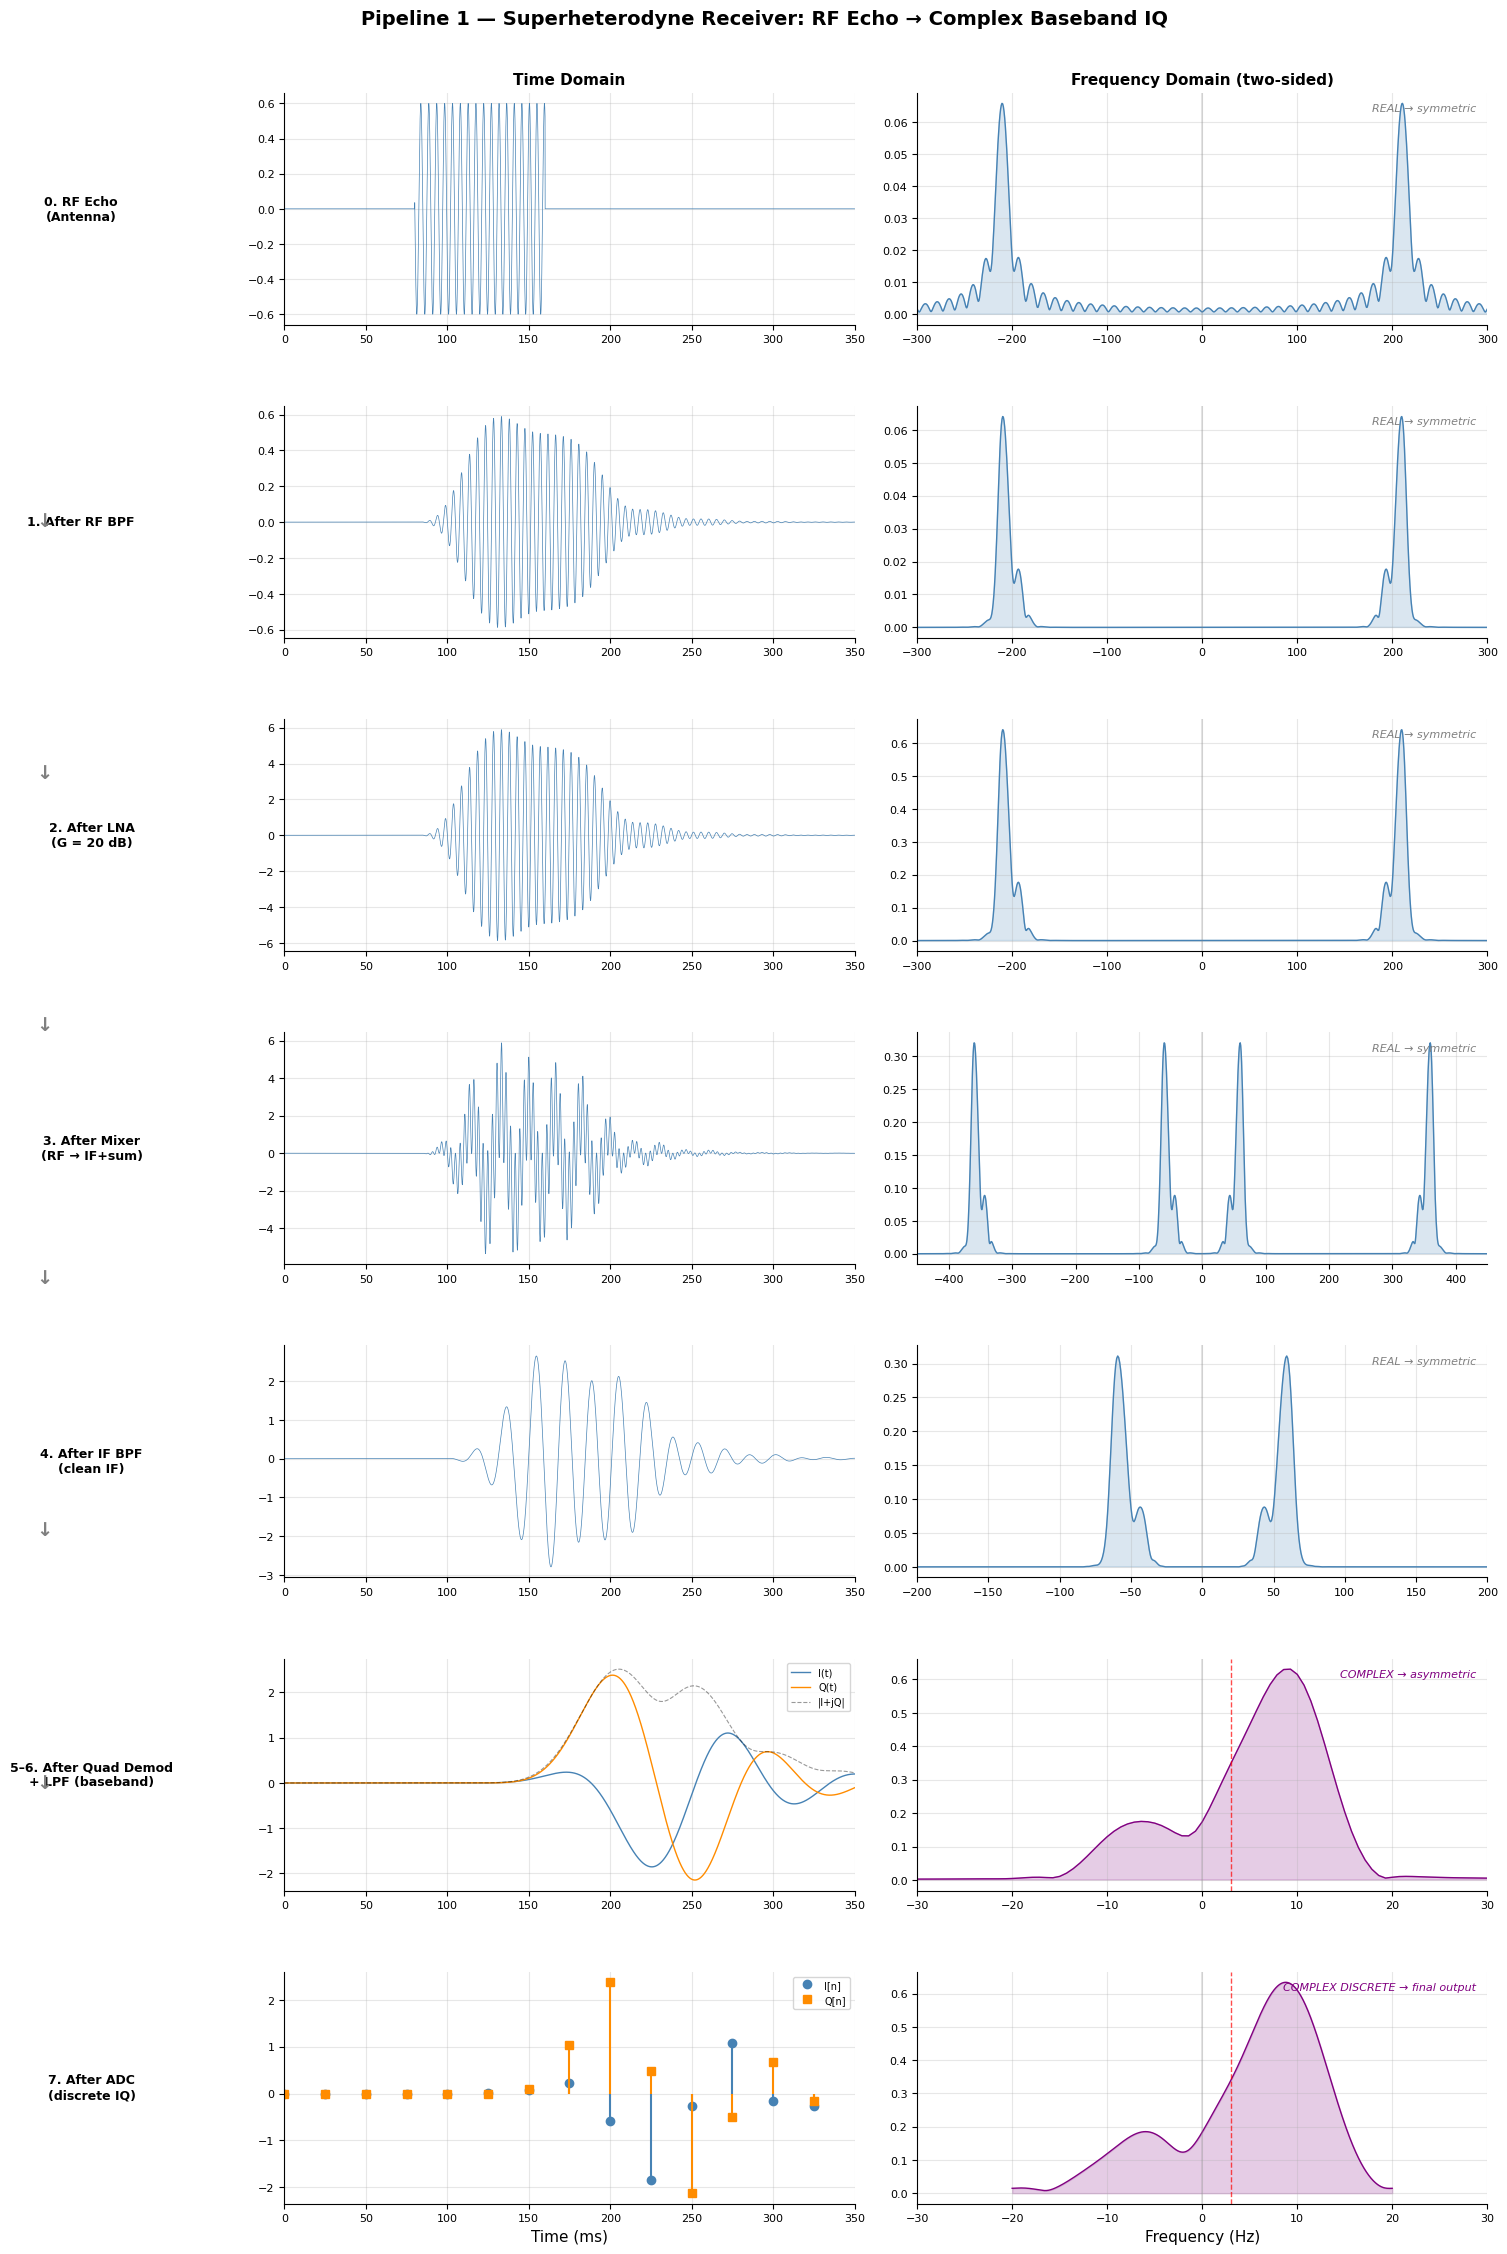

In [13]:
# ── Pipeline 1: Superheterodyne — full signal flow ──

# Collect all stages (reuse signals computed above)
superhet_stages = [
    ('0. RF Echo\n(Antenna)',         t_c, s_rf,        None,           'real', 300),
    ('1. After RF BPF',              t_c, s_after_bpf,  None,           'real', 300),
    ('2. After LNA\n(G = 20 dB)',    t_c, s_lna,        None,           'real', 300),
    ('3. After Mixer\n(RF → IF+sum)',t_c, s_mixed,      None,           'real', 450),
    ('4. After IF BPF\n(clean IF)',  t_c, s_if,         None,           'real', 200),
    ('5–6. After Quad Demod\n+ LPF (baseband)', t_c, None, s_bb_complex, 'complex', 30),
    ('7. After ADC\n(discrete IQ)',  t_n, None,  s_bb_discrete,         'discrete_complex', 30),
]

n_stages = len(superhet_stages)
fig, axes = plt.subplots(n_stages, 2, figsize=(15, 3.2 * n_stages))

for i, (label, t_sig, s_real, s_cplx, sig_type, xlim_freq) in enumerate(superhet_stages):
    ax_t, ax_f = axes[i]

    if sig_type == 'real':
        # Time domain
        ax_t.plot(t_sig * 1e3, s_real, color='steelblue', lw=0.5)
        ax_t.set_xlim(0, dur * 1e3)

        # Frequency domain (two-sided, symmetric)
        f, m = spectrum_twosided(s_real, t_sig)
        ax_f.fill_between(f, m, alpha=0.2, color='steelblue')
        ax_f.plot(f, m, 'steelblue', lw=1)
        ax_f.set_xlim(-xlim_freq, xlim_freq)
        ax_f.annotate('REAL → symmetric', xy=(0.98, 0.92), xycoords='axes fraction',
                       fontsize=8, ha='right', color='gray', style='italic')

    elif sig_type == 'complex':
        # Time domain — I and Q
        ax_t.plot(t_sig * 1e3, np.real(s_cplx), 'steelblue', lw=1, label='I(t)')
        ax_t.plot(t_sig * 1e3, np.imag(s_cplx), 'darkorange', lw=1, label='Q(t)')
        ax_t.plot(t_sig * 1e3, np.abs(s_cplx), 'k--', lw=0.8, alpha=0.4, label='|I+jQ|')
        ax_t.legend(fontsize=7, loc='upper right')
        ax_t.set_xlim(0, dur * 1e3)

        # Frequency domain (two-sided, NOT symmetric)
        f, m = complex_spectrum_twosided(s_cplx, t_sig)
        ax_f.fill_between(f, m, alpha=0.2, color='purple')
        ax_f.plot(f, m, 'purple', lw=1)
        ax_f.axvline(f_d, color='red', ls='--', lw=1, alpha=0.7)
        ax_f.set_xlim(-xlim_freq, xlim_freq)
        ax_f.annotate('COMPLEX → asymmetric', xy=(0.98, 0.92), xycoords='axes fraction',
                       fontsize=8, ha='right', color='purple', style='italic')

    elif sig_type == 'discrete_complex':
        # Time domain — discrete stems
        ax_t.stem(t_sig * 1e3, np.real(s_cplx), linefmt='steelblue', markerfmt='o', basefmt=' ',
                  label='I[n]')
        ax_t.stem(t_sig * 1e3, np.imag(s_cplx), linefmt='darkorange', markerfmt='s', basefmt=' ',
                  label='Q[n]')
        ax_t.legend(fontsize=7, loc='upper right')
        ax_t.set_xlim(0, dur * 1e3)

        # Frequency domain
        N_s = len(s_cplx)
        dt_s = t_sig[1] - t_sig[0] if len(t_sig) > 1 else Ts_adc
        nfft_s = max(N_s * 16, 4096)
        f = np.fft.fftshift(np.fft.fftfreq(nfft_s, dt_s))
        m = np.fft.fftshift(np.abs(np.fft.fft(s_cplx, n=nfft_s))) / N_s
        ax_f.fill_between(f, m, alpha=0.2, color='purple')
        ax_f.plot(f, m, 'purple', lw=1)
        ax_f.axvline(f_d, color='red', ls='--', lw=1, alpha=0.7)
        ax_f.set_xlim(-xlim_freq, xlim_freq)
        ax_f.annotate('COMPLEX DISCRETE → final output', xy=(0.98, 0.92),
                       xycoords='axes fraction', fontsize=8, ha='right', color='purple',
                       style='italic')

    # Labels
    ax_t.set_ylabel(label, fontsize=9, fontweight='bold', rotation=0, labelpad=120, va='center')
    ax_t.tick_params(labelsize=8)
    ax_f.tick_params(labelsize=8)
    ax_f.axvline(0, color='gray', ls='-', lw=0.3)

    if i == 0:
        ax_t.set_title('Time Domain', fontweight='bold', fontsize=11)
        ax_f.set_title('Frequency Domain (two-sided)', fontweight='bold', fontsize=11)
    if i == n_stages - 1:
        ax_t.set_xlabel('Time (ms)')
        ax_f.set_xlabel('Frequency (Hz)')

    # Draw arrow between rows
    if i < n_stages - 1:
        arrow_y = axes[i, 0].get_position().y0
        fig.text(0.02, arrow_y - 0.005, '↓', fontsize=14, ha='center', va='top',
                 fontweight='bold', color='gray')

plt.suptitle('Pipeline 1 — Superheterodyne Receiver: RF Echo → Complex Baseband IQ',
             fontweight='bold', fontsize=14, y=1.005)
plt.tight_layout()
plt.subplots_adjust(hspace=0.35, left=0.18)
plt.show()

## Pipeline 2 — Digital IF Receiver

```
Antenna → RF BPF → LNA → Mixer(×LO) → IF BPF → ADC → DDC(×e^{-j}) → Dig.LPF → ↓D → I[n]+jQ[n]
  (0)      (1)     (2)      (3)         (4)     (5)      (6)           (7)       (8)
```

Note: stages 0–4 are identical to the superheterodyne. The divergence begins at the ADC, which now digitizes the **real IF signal** before IQ extraction.

In [ ]:
# ── Pipeline 2: Digital IF — full signal flow ──

digif_stages = [
    ('0. RF Echo\n(Antenna)',           t_c,      s_rf,           None,              'real',             300),
    ('1. After RF BPF',                t_c,      s_after_bpf,    None,              'real',             300),
    ('2. After LNA\n(G = 20 dB)',      t_c,      s_lna,          None,              'real',             300),
    ('3. After Mixer\n(RF → IF+sum)',  t_c,      s_mixed,        None,              'real',             450),
    ('4. After IF BPF\n(clean IF)',    t_c,      s_if,           None,              'real',             200),
    ('5. ADC at IF\n(real, discrete)', t_if_n,   s_if_sampled,   None,              'discrete_real',    80),
    ('6. After DDC\n(×e^{−j2πf_IF nTs})', t_if_n, None,         s_ddc,             'discrete_complex', 80),
    ('7. After Dig. LPF\n(image removed)', t_if_n, None,         s_ddc_filtered,    'discrete_complex', 80),
    ('8. After Decimation\n(↓D, final)',   t_ddc_dec, None,      s_ddc_dec,         'discrete_complex', 30),
]

n_stages = len(digif_stages)
fig, axes = plt.subplots(n_stages, 2, figsize=(15, 3.2 * n_stages))

for i, (label, t_sig, s_real, s_cplx, sig_type, xlim_freq) in enumerate(digif_stages):
    ax_t, ax_f = axes[i]

    if sig_type == 'real':
        ax_t.plot(t_sig * 1e3, s_real, color='seagreen', lw=0.5)
        ax_t.set_xlim(0, dur * 1e3)
        f, m = spectrum_twosided(s_real, t_sig)
        ax_f.fill_between(f, m, alpha=0.2, color='seagreen')
        ax_f.plot(f, m, 'seagreen', lw=1)
        ax_f.set_xlim(-xlim_freq, xlim_freq)
        ax_f.annotate('REAL → symmetric', xy=(0.98, 0.92), xycoords='axes fraction',
                       fontsize=8, ha='right', color='gray', style='italic')

    elif sig_type == 'discrete_real':
        # Stem plot for real discrete
        zoom_dr = (t_sig >= 0.08) & (t_sig <= 0.16)
        ax_t.plot(t_c * 1e3, s_if, 'seagreen', lw=0.4, alpha=0.3)
        mk, st, _ = ax_t.stem(t_sig[zoom_dr] * 1e3, s_real[zoom_dr],
                               linefmt='C1-', markerfmt='C1o', basefmt=' ')
        plt.setp(mk, ms=3); plt.setp(st, lw=0.6)
        ax_t.set_xlim(70, 170)

        dt_s = t_sig[1] - t_sig[0]
        fs_s = 1.0 / dt_s
        N_s = len(s_real)
        nfft_s = max(N_s * 8, 4096)
        f = np.fft.fftshift(np.fft.fftfreq(nfft_s, dt_s))
        m = np.fft.fftshift(np.abs(np.fft.fft(s_real, n=nfft_s))) / N_s
        ax_f.fill_between(f, m, alpha=0.2, color='darkorange')
        ax_f.plot(f, m, 'darkorange', lw=1)
        ax_f.set_xlim(-xlim_freq, xlim_freq)
        ax_f.axvline(fs_s / 2, color='gray', ls=':', lw=0.8)
        ax_f.axvline(-fs_s / 2, color='gray', ls=':', lw=0.8)
        ax_f.annotate('REAL DISCRETE → symmetric', xy=(0.98, 0.92),
                       xycoords='axes fraction', fontsize=8, ha='right', color='gray',
                       style='italic')

    elif sig_type == 'discrete_complex':
        dt_s = t_sig[1] - t_sig[0] if len(t_sig) > 1 else Ts_adc
        fs_s = 1.0 / dt_s

        ax_t.plot(t_sig * 1e3, np.real(s_cplx), 'seagreen', lw=0.7, label='I[n]')
        ax_t.plot(t_sig * 1e3, np.imag(s_cplx), 'darkorange', lw=0.7, label='Q[n]')
        ax_t.legend(fontsize=7, loc='upper right')
        ax_t.set_xlim(0, dur * 1e3)

        N_s = len(s_cplx)
        nfft_s = max(N_s * 16, 4096)
        f = np.fft.fftshift(np.fft.fftfreq(nfft_s, dt_s))
        m = np.fft.fftshift(np.abs(np.fft.fft(s_cplx, n=nfft_s))) / N_s
        ax_f.fill_between(f, m, alpha=0.2, color='purple')
        ax_f.plot(f, m, 'purple', lw=1)
        ax_f.set_xlim(-xlim_freq, xlim_freq)

        is_final = (i == n_stages - 1)
        if is_final:
            ax_f.axvline(f_d, color='red', ls='--', lw=1, alpha=0.7)
        ax_f.annotate('COMPLEX DISCRETE' + (' → final' if is_final else ''),
                       xy=(0.98, 0.92), xycoords='axes fraction', fontsize=8,
                       ha='right', color='purple', style='italic')

    # Labels
    ax_t.set_ylabel(label, fontsize=9, fontweight='bold', rotation=0, labelpad=130, va='center')
    ax_t.tick_params(labelsize=8)
    ax_f.tick_params(labelsize=8)
    ax_f.axvline(0, color='gray', ls='-', lw=0.3)

    if i == 0:
        ax_t.set_title('Time Domain', fontweight='bold', fontsize=11)
        ax_f.set_title('Frequency Domain (two-sided)', fontweight='bold', fontsize=11)
    if i == n_stages - 1:
        ax_t.set_xlabel('Time (ms)')
        ax_f.set_xlabel('Frequency (Hz)')

plt.suptitle('Pipeline 2 — Digital IF Receiver: RF Echo → DDC → Complex Baseband IQ',
             fontweight='bold', fontsize=14, y=1.005)
plt.tight_layout()
plt.subplots_adjust(hspace=0.35, left=0.2)
plt.show()

## Pipeline 3 — Homodyne (Direct Conversion)

```
Antenna → RF BPF → LNA → Quad Mixer(×LO at f_RF) → LPF → ADC → I[n]+jQ[n]
  (0)      (1)     (2)           (3)                 (4)   (5)
```

Shortest chain — no IF stage. Mixer LO is at RF frequency, so difference product lands directly at baseband.

In [ ]:
# ── Pipeline 3: Homodyne — full signal flow ──

# Recompute intermediate homodyne signals for the raw (before LPF) stage
I_hom_raw_full = s_lna * 2 * np.cos(2 * np.pi * f_rf * t_c)
Q_hom_raw_full = s_lna * (-2) * np.sin(2 * np.pi * f_rf * t_c)

homodyne_stages = [
    ('0. RF Echo\n(Antenna)',              t_c,    s_rf,              None,              'real',             300),
    ('1. After RF BPF',                   t_c,    s_after_bpf,       None,              'real',             300),
    ('2. After LNA\n(G = 20 dB)',         t_c,    s_lna,             None,              'real',             300),
    ('3. Quad Mixer\n(×cos, ×−sin at f_RF)', t_c, None, (I_hom_raw_full + 1j * Q_hom_raw_full), 'complex', 450),
    ('4. After LPF\n(baseband I,Q)',      t_c,    None, s_homodyne_complex,              'complex',         30),
    ('5. After ADC\n(discrete IQ)',       t_hom_n, None, s_hom_discrete,                 'discrete_complex', 30),
]

n_stages = len(homodyne_stages)
fig, axes = plt.subplots(n_stages, 2, figsize=(15, 3.2 * n_stages))

for i, (label, t_sig, s_real, s_cplx, sig_type, xlim_freq) in enumerate(homodyne_stages):
    ax_t, ax_f = axes[i]

    if sig_type == 'real':
        ax_t.plot(t_sig * 1e3, s_real, color='darkorange', lw=0.5)
        ax_t.set_xlim(0, dur * 1e3)
        f, m = spectrum_twosided(s_real, t_sig)
        ax_f.fill_between(f, m, alpha=0.2, color='darkorange')
        ax_f.plot(f, m, 'darkorange', lw=1)
        ax_f.set_xlim(-xlim_freq, xlim_freq)
        ax_f.annotate('REAL → symmetric', xy=(0.98, 0.92), xycoords='axes fraction',
                       fontsize=8, ha='right', color='gray', style='italic')

    elif sig_type == 'complex':
        ax_t.plot(t_sig * 1e3, np.real(s_cplx), 'darkorange', lw=0.7, label='I(t)')
        ax_t.plot(t_sig * 1e3, np.imag(s_cplx), 'steelblue', lw=0.7, label='Q(t)')
        ax_t.plot(t_sig * 1e3, np.abs(s_cplx), 'k--', lw=0.8, alpha=0.4, label='|I+jQ|')
        ax_t.legend(fontsize=7, loc='upper right')
        ax_t.set_xlim(0, dur * 1e3)

        f, m = complex_spectrum_twosided(s_cplx, t_sig)
        ax_f.fill_between(f, m, alpha=0.2, color='purple')
        ax_f.plot(f, m, 'purple', lw=1)
        ax_f.set_xlim(-xlim_freq, xlim_freq)
        is_bb = (xlim_freq <= 50)
        if is_bb:
            ax_f.axvline(f_d, color='red', ls='--', lw=1, alpha=0.7)
        ax_f.annotate('COMPLEX → asymmetric', xy=(0.98, 0.92), xycoords='axes fraction',
                       fontsize=8, ha='right', color='purple', style='italic')

    elif sig_type == 'discrete_complex':
        ax_t.stem(t_sig * 1e3, np.real(s_cplx), linefmt='darkorange', markerfmt='o', basefmt=' ',
                  label='I[n]')
        ax_t.stem(t_sig * 1e3, np.imag(s_cplx), linefmt='steelblue', markerfmt='s', basefmt=' ',
                  label='Q[n]')
        ax_t.legend(fontsize=7, loc='upper right')
        ax_t.set_xlim(0, dur * 1e3)

        N_s = len(s_cplx)
        dt_s = t_sig[1] - t_sig[0] if len(t_sig) > 1 else Ts_adc
        nfft_s = max(N_s * 16, 4096)
        f = np.fft.fftshift(np.fft.fftfreq(nfft_s, dt_s))
        m = np.fft.fftshift(np.abs(np.fft.fft(s_cplx, n=nfft_s))) / N_s
        ax_f.fill_between(f, m, alpha=0.2, color='purple')
        ax_f.plot(f, m, 'purple', lw=1)
        ax_f.axvline(f_d, color='red', ls='--', lw=1, alpha=0.7)
        ax_f.set_xlim(-xlim_freq, xlim_freq)
        ax_f.annotate('COMPLEX DISCRETE → final output', xy=(0.98, 0.92),
                       xycoords='axes fraction', fontsize=8, ha='right', color='purple',
                       style='italic')

    # Labels
    ax_t.set_ylabel(label, fontsize=9, fontweight='bold', rotation=0, labelpad=130, va='center')
    ax_t.tick_params(labelsize=8)
    ax_f.tick_params(labelsize=8)
    ax_f.axvline(0, color='gray', ls='-', lw=0.3)

    if i == 0:
        ax_t.set_title('Time Domain', fontweight='bold', fontsize=11)
        ax_f.set_title('Frequency Domain (two-sided)', fontweight='bold', fontsize=11)
    if i == n_stages - 1:
        ax_t.set_xlabel('Time (ms)')
        ax_f.set_xlabel('Frequency (Hz)')

plt.suptitle('Pipeline 3 — Homodyne Receiver: RF Echo → Direct Conversion → Complex Baseband IQ',
             fontweight='bold', fontsize=14, y=1.005)
plt.tight_layout()
plt.subplots_adjust(hspace=0.35, left=0.2)
plt.show()